In [1]:

!pip install -q shap lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


## 1. Imports, deterministic configuration, and output directories

In [2]:
from __future__ import annotations

import hashlib
import inspect
import json
import os
import platform
import shutil
import sys
from pathlib import Path
from typing import Any

import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
from IPython.display import display
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    matthews_corrcoef,
    ndcg_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import ParameterGrid, RandomizedSearchCV, StratifiedGroupKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Environment variables permit a quick smoke test without editing the notebook.
FAST_MODE = os.getenv("FAST_MODE", "0") == "1"
RUN_EXPLAINABILITY = os.getenv("RUN_EXPLAINABILITY", "1") == "1"
RESET_OUTPUT_DIR = os.getenv("RESET_OUTPUT_DIR", "1") == "1"

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

OUTER_SPLITS = 3 if FAST_MODE else 5
INNER_SPLITS = 2 if FAST_MODE else 4
FINAL_TUNING_SPLITS = 3 if FAST_MODE else 5

SEARCH_ITERATIONS = 1 if FAST_MODE else 15
N_BOOTSTRAP = 30 if FAST_MODE else 2000
ROC_BOOTSTRAP = 30 if FAST_MODE else 1000
RANKING_BOOTSTRAP = 30 if FAST_MODE else 2000
AUC_DIFFERENCE_BOOTSTRAP = 30 if FAST_MODE else 2000
THRESHOLD_BOOTSTRAP = 30 if FAST_MODE else 1000
PERMUTATION_REPEATS = 5 if FAST_MODE else 50

SHAP_BACKGROUND_SIZE = 20 if FAST_MODE else 80
SHAP_EXPLANATION_SIZE = 12 if FAST_MODE else 100
SHAP_PERMUTATION_CYCLES = 2 if FAST_MODE else 10
LIME_NUM_SAMPLES = 800 if FAST_MODE else 5000
LIME_SEEDS = [42, 43] if FAST_MODE else [42, 43, 44, 45, 46]

N_JOBS = int(os.getenv("N_JOBS", "2"))
TREE_ESTIMATORS = 50 if FAST_MODE else 300
FEASIBILITY_THRESHOLD = 0.60
MODEL_SELECTION_METRIC = "roc_auc"
CALIBRATION_METHOD = "sigmoid"

OUTPUT_DIR = Path(
    os.getenv(
        "CLASSICAL_OUTPUT_DIR",
        "/content/final_classical_ml_quantum_routing_results",
    )
)

if RESET_OUTPUT_DIR and OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
MODEL_DIR = OUTPUT_DIR / "models"
EXPLANATION_DIR = OUTPUT_DIR / "explainability"

for directory in [FIGURE_DIR, TABLE_DIR, MODEL_DIR, EXPLANATION_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 600,
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

print("FAST_MODE:", FAST_MODE)
print("RUN_EXPLAINABILITY:", RUN_EXPLAINABILITY)
print("Python:", platform.python_version())
print("scikit-learn:", sklearn.__version__)
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("SciPy:", scipy.__version__)
print("Output directory:", OUTPUT_DIR)

FAST_MODE: False
RUN_EXPLAINABILITY: True
Python: 3.12.13
scikit-learn: 1.6.1
NumPy: 2.0.2
pandas: 2.2.2
SciPy: 1.16.3
Output directory: /content/final_classical_ml_quantum_routing_results


## 2. Resolve and load the three fixed CSV files

In [3]:
MODEL_FEATURES = [
    "hop_count",
    "total_fibre_loss_db",
    "maximum_link_loss_db",
    "bottleneck_link_success_estimate",
    "min_memory_requirement_margin",
    "fidelity_margin_estimate",
    "deadline_margin_ms",
    "route_degraded_link_fraction",
    "route_contains_hotspot",
    "effective_efficiency",
    "coherence_time_s",
]

TARGET = "feasible_label"
PROBABILITY_TARGET = "success_probability"
GROUP_COLUMN = "scenario_group_id"
RANKING_GROUP_COLUMN = "ranking_group_id"


def resolve_csv_path(exact_name: str, glob_pattern: str) -> Path:
    search_roots = [Path("/content"), Path("/mnt/data"), Path.cwd()]

    for root in search_roots:
        exact = root / exact_name
        if exact.exists():
            return exact

    matches: list[Path] = []
    for root in search_roots:
        if root.exists():
            matches.extend(root.glob(glob_pattern))

    unique_matches = sorted(
        {path.resolve() for path in matches if path.is_file()},
        key=lambda path: (len(path.name), path.name),
    )

    if not unique_matches:
        raise FileNotFoundError(
            f"Could not find {exact_name}. Upload it to /content or set the path manually."
        )

    chosen = unique_matches[0]
    print(f"Resolved {exact_name} to {chosen}")
    return chosen


TRAIN_PATH = resolve_csv_path("model_ready_train.csv", "model_ready_train*.csv")
VALIDATION_PATH = resolve_csv_path(
    "model_ready_validation.csv", "model_ready_validation*.csv"
)
TEST_PATH = resolve_csv_path(
    "model_ready_external_test.csv", "model_ready_external_test*.csv"
)

train_df = pd.read_csv(TRAIN_PATH)
validation_df = pd.read_csv(VALIDATION_PATH)
test_df = pd.read_csv(TEST_PATH)

SPLIT_FRAMES = {
    "Train": train_df,
    "Validation": validation_df,
    "External test": test_df,
}

for split_name, frame in SPLIT_FRAMES.items():
    print(
        f"{split_name:13s} | rows={len(frame):4d} | "
        f"scenarios={frame[GROUP_COLUMN].nunique():3d} | "
        f"ranking_groups={frame[RANKING_GROUP_COLUMN].nunique():3d} | "
        f"feasible={frame[TARGET].mean():.3f}"
    )

Train         | rows= 960 | scenarios= 60 | ranking_groups=240 | feasible=0.535
Validation    | rows= 240 | scenarios= 15 | ranking_groups= 60 | feasible=0.554
External test | rows= 480 | scenarios= 30 | ranking_groups=120 | feasible=0.669


## 3. Comprehensive integrity, leakage, and grouping audit

In [4]:
REQUIRED_COLUMNS = set(
    MODEL_FEATURES
    + [
        TARGET,
        PROBABILITY_TARGET,
        GROUP_COLUMN,
        RANKING_GROUP_COLUMN,
        "route_id",
        "rollout_count",
        "success_count",
        "difficulty",
        "topology_id",
    ]
)

FORBIDDEN_MODEL_COLUMNS = {
    TARGET,
    PROBABILITY_TARGET,
    "success_count",
    "rollout_count",
    "success_probability_wilson_lower",
    "success_probability_wilson_upper",
    "selected_route",
    "oracle_route",
}

leaking_columns = sorted(set(MODEL_FEATURES) & FORBIDDEN_MODEL_COLUMNS)
if leaking_columns:
    raise ValueError(f"Outcome-derived columns found in MODEL_FEATURES: {leaking_columns}")

ROUTE_KEY = ["topology_id", GROUP_COLUMN, RANKING_GROUP_COLUMN, "route_id"]


def audit_split(name: str, frame: pd.DataFrame) -> dict[str, Any]:
    missing_columns = sorted(REQUIRED_COLUMNS.difference(frame.columns))
    if missing_columns:
        raise ValueError(f"{name} is missing columns: {missing_columns}")

    required_frame = frame[list(REQUIRED_COLUMNS)]
    if required_frame.isna().any().any():
        missing = required_frame.isna().sum()
        raise ValueError(f"{name} contains missing required values:\n{missing[missing > 0]}")

    non_numeric = [
        feature
        for feature in MODEL_FEATURES
        if not pd.api.types.is_numeric_dtype(frame[feature])
    ]
    if non_numeric:
        raise TypeError(f"{name} has non-numeric model features: {non_numeric}")

    feature_values = frame[MODEL_FEATURES].to_numpy(dtype=float)
    if not np.isfinite(feature_values).all():
        raise ValueError(f"{name} contains non-finite model-feature values.")

    target_values = set(frame[TARGET].astype(int).unique())
    if not target_values.issubset({0, 1}):
        raise ValueError(f"{name} target is not binary: {target_values}")

    if (frame["rollout_count"] <= 0).any():
        raise ValueError(f"{name} contains non-positive rollout_count values.")

    if (
        (frame["success_count"] < 0)
        | (frame["success_count"] > frame["rollout_count"])
    ).any():
        raise ValueError(f"{name} has invalid success_count values.")

    expected_label = (frame[PROBABILITY_TARGET] >= FEASIBILITY_THRESHOLD).astype(int)
    label_mismatches = int((expected_label != frame[TARGET].astype(int)).sum())

    expected_probability = frame["success_count"] / frame["rollout_count"]
    probability_mismatches = int(
        (~np.isclose(expected_probability, frame[PROBABILITY_TARGET])).sum()
    )

    duplicate_full_rows = int(frame.duplicated().sum())
    duplicate_route_keys = int(frame.duplicated(subset=ROUTE_KEY).sum())

    routes_per_group = frame.groupby(RANKING_GROUP_COLUMN)["route_id"].nunique()
    incorrect_route_group_count = int((routes_per_group != 4).sum())

    consistency_columns = [GROUP_COLUMN, "topology_id", "difficulty"]
    if "pair_id" in frame.columns:
        consistency_columns.append("pair_id")

    inconsistent_group_fields = 0
    for column in consistency_columns:
        inconsistent_group_fields += int(
            (frame.groupby(RANKING_GROUP_COLUMN)[column].nunique() != 1).sum()
        )

    return {
        "Split": name,
        "Rows": len(frame),
        "Scenarios": frame[GROUP_COLUMN].nunique(),
        "Ranking groups": frame[RANKING_GROUP_COLUMN].nunique(),
        "Feasible rate": frame[TARGET].mean(),
        "Duplicate full rows": duplicate_full_rows,
        "Duplicate route keys": duplicate_route_keys,
        "Label mismatches": label_mismatches,
        "Probability mismatches": probability_mismatches,
        "Ranking groups not containing four unique routes": incorrect_route_group_count,
        "Inconsistent ranking-group metadata fields": inconsistent_group_fields,
        "Minimum routes per ranking group": routes_per_group.min(),
        "Maximum routes per ranking group": routes_per_group.max(),
    }


audit_table = pd.DataFrame(
    [audit_split(name, frame) for name, frame in SPLIT_FRAMES.items()]
)
display(audit_table)

audit_failure_columns = [
    "Duplicate full rows",
    "Duplicate route keys",
    "Label mismatches",
    "Probability mismatches",
    "Ranking groups not containing four unique routes",
    "Inconsistent ranking-group metadata fields",
]

if audit_table[audit_failure_columns].to_numpy().sum() != 0:
    raise AssertionError("Dataset-integrity audit failed. Inspect audit_table.")

train_groups = set(train_df[GROUP_COLUMN].astype(str))
validation_groups = set(validation_df[GROUP_COLUMN].astype(str))
test_groups = set(test_df[GROUP_COLUMN].astype(str))

if not train_groups.isdisjoint(validation_groups):
    raise AssertionError("Training and validation scenario groups overlap.")
if not train_groups.isdisjoint(test_groups):
    raise AssertionError("Training and external-test scenario groups overlap.")
if not validation_groups.isdisjoint(test_groups):
    raise AssertionError("Validation and external-test scenario groups overlap.")

audit_table.to_csv(TABLE_DIR / "data_integrity_audit.csv", index=False)
print("All integrity, leakage, and split-overlap checks passed.")

,Split,Rows,Scenarios,Ranking groups,Feasible rate,Duplicate full rows,Duplicate route keys,Label mismatches,Probability mismatches,Ranking groups not containing four unique routes,Inconsistent ranking-group metadata fields,Minimum routes per ranking group,Maximum routes per ranking group
0,Train,960,60,240,0.535417,0,0,0,0,0,0,4,4
1,Validation,240,15,60,0.554167,0,0,0,0,0,0,4,4
2,External test,480,30,120,0.668750,0,0,0,0,0,0,4,4


All integrity, leakage, and split-overlap checks passed.


## 4. Prepare matrices and freeze reproducible grouped folds

In [5]:
X_train = train_df[MODEL_FEATURES].copy()
y_train = train_df[TARGET].astype(int).copy()
groups_train = train_df[GROUP_COLUMN].astype(str).copy()

X_validation = validation_df[MODEL_FEATURES].copy()
y_validation = validation_df[TARGET].astype(int).copy()
groups_validation = validation_df[GROUP_COLUMN].astype(str).copy()

X_test = test_df[MODEL_FEATURES].copy()
y_test = test_df[TARGET].astype(int).copy()
groups_test = test_df[GROUP_COLUMN].astype(str).copy()


def materialize_group_splits(
    X: pd.DataFrame,
    y: pd.Series,
    groups: pd.Series,
    n_splits: int,
    seed: int,
) -> list[tuple[np.ndarray, np.ndarray]]:
    splitter = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=seed,
    )
    splits = list(splitter.split(X, y, groups))

    for fold_number, (fit_indices, holdout_indices) in enumerate(splits, start=1):
        fit_groups = set(groups.iloc[fit_indices])
        holdout_groups = set(groups.iloc[holdout_indices])
        if not fit_groups.isdisjoint(holdout_groups):
            raise AssertionError(f"Group leakage in fold {fold_number}.")
        if y.iloc[fit_indices].nunique() < 2 or y.iloc[holdout_indices].nunique() < 2:
            raise ValueError(
                f"Fold {fold_number} lacks both classes. Reduce n_splits or revise groups."
            )

    return splits


OUTER_CV_SPLITS = materialize_group_splits(
    X_train,
    y_train,
    groups_train,
    n_splits=OUTER_SPLITS,
    seed=RANDOM_SEED,
)

fold_assignment = np.full(len(train_df), -1, dtype=int)
fold_audit_rows = []

for fold_number, (fit_indices, holdout_indices) in enumerate(
    OUTER_CV_SPLITS, start=1
):
    fold_assignment[holdout_indices] = fold_number
    fold_audit_rows.append(
        {
            "Fold": fold_number,
            "Training rows": len(fit_indices),
            "Holdout rows": len(holdout_indices),
            "Training scenarios": groups_train.iloc[fit_indices].nunique(),
            "Holdout scenarios": groups_train.iloc[holdout_indices].nunique(),
            "Training feasible rate": y_train.iloc[fit_indices].mean(),
            "Holdout feasible rate": y_train.iloc[holdout_indices].mean(),
        }
    )

if (fold_assignment < 1).any():
    raise AssertionError("At least one training row was not assigned to an outer fold.")

fold_audit = pd.DataFrame(fold_audit_rows)
display(fold_audit)
fold_audit.to_csv(TABLE_DIR / "outer_five_fold_group_audit.csv", index=False)

fold_assignment_columns = [
    column
    for column in [
        "topology_id",
        GROUP_COLUMN,
        RANKING_GROUP_COLUMN,
        "pair_id",
        "route_id",
    ]
    if column in train_df.columns
]

fold_assignment_table = train_df[fold_assignment_columns].copy()
fold_assignment_table["outer_holdout_fold"] = fold_assignment
fold_assignment_table.to_csv(
    TABLE_DIR / "training_outer_fold_assignments.csv", index=False
)

,Fold,Training rows,Holdout rows,Training scenarios,Holdout scenarios,Training feasible rate,Holdout feasible rate
0,1,768,192,48,12,0.519531,0.598958
1,2,768,192,48,12,0.557292,0.447917
2,3,768,192,48,12,0.513021,0.625000
3,4,768,192,48,12,0.545573,0.494792
4,5,768,192,48,12,0.541667,0.510417


## 5. Candidate models and hyperparameter spaces

In [6]:
def scaled_pipeline(model: Any) -> Pipeline:
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", model),
        ]
    )


def tree_pipeline(model: Any) -> Pipeline:
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", model),
        ]
    )


MODEL_SPECS: dict[str, dict[str, Any]] = {
    "Dummy prior": {
        "estimator": tree_pipeline(DummyClassifier(strategy="prior")),
        "parameters": {"model__strategy": ["prior"]},
    },
    "Logistic regression": {
        "estimator": scaled_pipeline(
            LogisticRegression(
                solver="lbfgs",
                max_iter=5000,
                random_state=RANDOM_SEED,
            )
        ),
        "parameters": {
            "model__C": [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0],
            "model__class_weight": [None, "balanced"],
        },
    },
    "K-nearest neighbors": {
        "estimator": scaled_pipeline(KNeighborsClassifier()),
        "parameters": {
            "model__n_neighbors": [3, 5, 7, 9, 13, 17, 25, 35],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2],
        },
    },
    "RBF SVM": {
        "estimator": scaled_pipeline(
            SVC(
                kernel="rbf",
                probability=False,
                random_state=RANDOM_SEED,
            )
        ),
        "parameters": {
            "model__C": [0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0],
            "model__gamma": ["scale", "auto", 0.003, 0.01, 0.03, 0.1, 0.3, 1.0],
            "model__class_weight": [None, "balanced"],
        },
    },
    "Random forest": {
        "estimator": tree_pipeline(
            RandomForestClassifier(
                n_estimators=TREE_ESTIMATORS,
                n_jobs=1,
                random_state=RANDOM_SEED,
            )
        ),
        "parameters": {
            "model__max_depth": [None, 4, 6, 8, 12, 16],
            "model__min_samples_split": [2, 5, 10, 20],
            "model__min_samples_leaf": [1, 2, 4, 8, 12],
            "model__max_features": ["sqrt", "log2", 0.6, 0.8, 1.0],
            "model__class_weight": [None, "balanced", "balanced_subsample"],
        },
    },
    "Extra trees": {
        "estimator": tree_pipeline(
            ExtraTreesClassifier(
                n_estimators=TREE_ESTIMATORS,
                n_jobs=1,
                random_state=RANDOM_SEED,
            )
        ),
        "parameters": {
            "model__max_depth": [None, 4, 6, 8, 12, 16],
            "model__min_samples_split": [2, 5, 10, 20],
            "model__min_samples_leaf": [1, 2, 4, 8, 12],
            "model__max_features": ["sqrt", "log2", 0.6, 0.8, 1.0],
            "model__class_weight": [None, "balanced"],
        },
    },
    "Gradient boosting": {
        "estimator": tree_pipeline(
            GradientBoostingClassifier(random_state=RANDOM_SEED)
        ),
        "parameters": {
            "model__n_estimators": [75, 100, 150, 200, 300],
            "model__learning_rate": [0.02, 0.03, 0.05, 0.08, 0.1, 0.15],
            "model__max_depth": [1, 2, 3, 4, 5],
            "model__min_samples_leaf": [1, 2, 4, 8, 12],
            "model__subsample": [0.7, 0.85, 1.0],
            "model__max_features": [None, "sqrt", 0.7, 1.0],
        },
    },
}

SCORING = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "balanced_accuracy": "balanced_accuracy",
    "f1": "f1",
}

for model_name in MODEL_SPECS:
    print("-", model_name)

- Dummy prior
- Logistic regression
- K-nearest neighbors
- RBF SVM
- Random forest
- Extra trees
- Gradient boosting


## 6. Nested grouped cross-validation for unbiased model-family comparison

In [7]:
def continuous_score(estimator: Any, X: pd.DataFrame) -> np.ndarray:
    if hasattr(estimator, "predict_proba"):
        probabilities = estimator.predict_proba(X)
        return np.asarray(probabilities)[:, 1]
    if hasattr(estimator, "decision_function"):
        scores = estimator.decision_function(X)
        return np.asarray(scores, dtype=float).reshape(-1)
    raise TypeError("Estimator exposes neither predict_proba nor decision_function.")


def number_of_configurations(parameter_space: dict[str, list[Any]]) -> int:
    return len(list(ParameterGrid(parameter_space)))


nested_oof_scores = {
    model_name: np.full(len(X_train), np.nan, dtype=float)
    for model_name in MODEL_SPECS
}
nested_oof_default_predictions = {
    model_name: np.full(len(X_train), -1, dtype=int)
    for model_name in MODEL_SPECS
}
nested_best_parameters: dict[str, dict[int, dict[str, Any]]] = {
    model_name: {} for model_name in MODEL_SPECS
}

nested_fold_rows: list[dict[str, Any]] = []
nested_inner_audit_rows: list[dict[str, Any]] = []

for outer_fold, (outer_fit_indices, outer_holdout_indices) in enumerate(
    OUTER_CV_SPLITS, start=1
):
    X_outer_fit = X_train.iloc[outer_fit_indices]
    y_outer_fit = y_train.iloc[outer_fit_indices]
    groups_outer_fit = groups_train.iloc[outer_fit_indices]

    X_outer_holdout = X_train.iloc[outer_holdout_indices]
    y_outer_holdout = y_train.iloc[outer_holdout_indices]

    inner_splits = materialize_group_splits(
        X_outer_fit,
        y_outer_fit,
        groups_outer_fit,
        n_splits=INNER_SPLITS,
        seed=RANDOM_SEED + outer_fold,
    )

    for inner_fold, (inner_fit, inner_holdout) in enumerate(inner_splits, start=1):
        nested_inner_audit_rows.append(
            {
                "Outer fold": outer_fold,
                "Inner fold": inner_fold,
                "Inner training rows": len(inner_fit),
                "Inner holdout rows": len(inner_holdout),
                "Inner training scenarios": groups_outer_fit.iloc[inner_fit].nunique(),
                "Inner holdout scenarios": groups_outer_fit.iloc[inner_holdout].nunique(),
                "Inner holdout feasible rate": y_outer_fit.iloc[inner_holdout].mean(),
            }
        )

    print(f"Outer fold {outer_fold}/{OUTER_SPLITS}")

    for model_name, specification in MODEL_SPECS.items():
        parameter_space = specification["parameters"]
        total_combinations = number_of_configurations(parameter_space)
        n_iterations = min(SEARCH_ITERATIONS, total_combinations)

        search = RandomizedSearchCV(
            estimator=clone(specification["estimator"]),
            param_distributions=parameter_space,
            n_iter=n_iterations,
            scoring=SCORING,
            refit=MODEL_SELECTION_METRIC,
            cv=inner_splits,
            n_jobs=N_JOBS,
            random_state=RANDOM_SEED,
            return_train_score=False,
            error_score="raise",
            verbose=0,
        )
        search.fit(X_outer_fit, y_outer_fit)

        best_estimator = search.best_estimator_
        holdout_scores = continuous_score(best_estimator, X_outer_holdout)
        holdout_predictions = best_estimator.predict(X_outer_holdout).astype(int)

        nested_oof_scores[model_name][outer_holdout_indices] = holdout_scores
        nested_oof_default_predictions[model_name][outer_holdout_indices] = (
            holdout_predictions
        )
        nested_best_parameters[model_name][outer_fold] = search.best_params_

        nested_fold_rows.append(
            {
                "Model": model_name,
                "Outer fold": outer_fold,
                "ROC-AUC": roc_auc_score(y_outer_holdout, holdout_scores),
                "Average precision": average_precision_score(
                    y_outer_holdout, holdout_scores
                ),
                "Balanced accuracy": balanced_accuracy_score(
                    y_outer_holdout, holdout_predictions
                ),
                "F1": f1_score(
                    y_outer_holdout, holdout_predictions, zero_division=0
                ),
                "Inner best ROC-AUC": search.best_score_,
                "Configurations evaluated": n_iterations,
                "Best inner parameters": json.dumps(
                    search.best_params_, sort_keys=True
                ),
            }
        )

for model_name in MODEL_SPECS:
    if np.isnan(nested_oof_scores[model_name]).any():
        raise AssertionError(f"Missing nested OOF scores for {model_name}.")
    if (nested_oof_default_predictions[model_name] < 0).any():
        raise AssertionError(f"Missing nested OOF predictions for {model_name}.")

nested_fold_results = pd.DataFrame(nested_fold_rows)
nested_inner_audit = pd.DataFrame(nested_inner_audit_rows)

nested_fold_results.to_csv(
    TABLE_DIR / "nested_outer_fold_model_results.csv", index=False
)
nested_inner_audit.to_csv(
    TABLE_DIR / "nested_inner_fold_audit.csv", index=False
)

Outer fold 1/5
Outer fold 2/5
Outer fold 3/5
Outer fold 4/5
Outer fold 5/5


## 7. Model comparison, one-standard-error competitive set, and paired AUC differences

,Model,Nested CV ROC-AUC mean,Nested CV ROC-AUC SD,Nested CV average precision mean,Nested CV balanced accuracy mean,Nested CV F1 mean,Pooled nested OOF ROC-AUC,Pooled nested OOF average precision,Pooled nested OOF balanced accuracy,Pooled nested OOF F1,Within one SE of best
0,Logistic regression,0.944119,0.016499,0.951570,0.837998,0.852304,0.934280,0.946400,0.851551,0.858556,True
1,Extra trees,0.939682,0.030417,0.941388,0.839839,0.855005,0.934131,0.946974,0.851337,0.861868,True
2,RBF SVM,0.939138,0.019215,0.947277,0.840222,0.850708,0.934018,0.946972,0.849457,0.856578,True
3,Gradient boosting,0.932643,0.029541,0.938984,0.790038,0.810277,0.925226,0.941187,0.808553,0.818182,False
4,Random forest,0.927611,0.026825,0.937028,0.805600,0.830817,0.923690,0.936232,0.821662,0.838586,False
5,K-nearest neighbors,0.894403,0.048505,0.904264,0.807958,0.827861,0.897485,0.911228,0.809775,0.828897,False
6,Dummy prior,0.500000,0.000000,0.535417,0.500000,0.695001,0.426297,0.494194,0.500000,0.697422,False


Numerically selected model family: Logistic regression
Models within one standard error of the best: ['Logistic regression', 'Extra trees', 'RBF SVM']


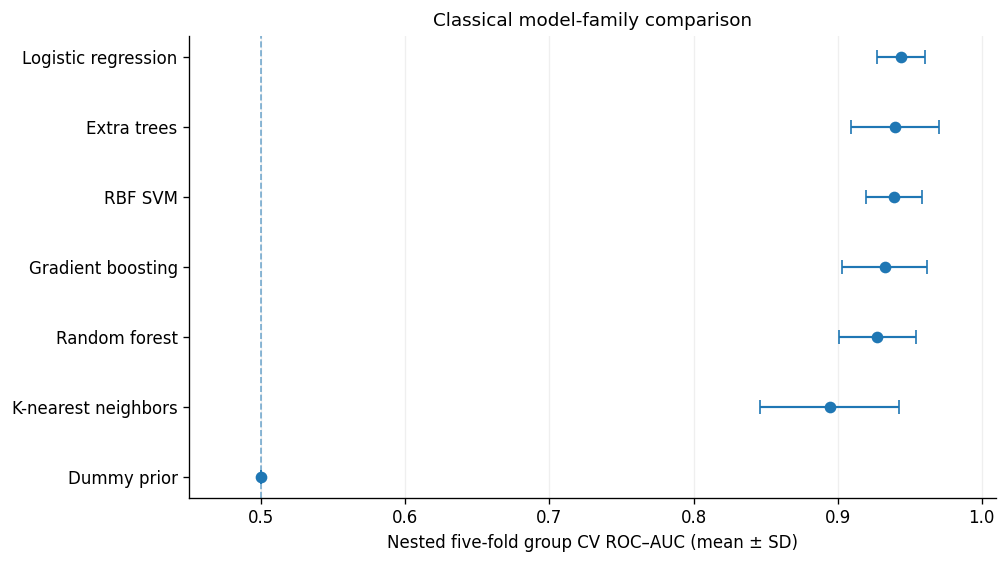

In [8]:
comparison_rows = []

for model_name in MODEL_SPECS:
    fold_subset = nested_fold_results.loc[
        nested_fold_results["Model"] == model_name
    ]
    oof_scores = nested_oof_scores[model_name]
    oof_predictions = nested_oof_default_predictions[model_name]

    comparison_rows.append(
        {
            "Model": model_name,
            "Nested CV ROC-AUC mean": fold_subset["ROC-AUC"].mean(),
            "Nested CV ROC-AUC SD": fold_subset["ROC-AUC"].std(ddof=1),
            "Nested CV average precision mean": fold_subset[
                "Average precision"
            ].mean(),
            "Nested CV balanced accuracy mean": fold_subset[
                "Balanced accuracy"
            ].mean(),
            "Nested CV F1 mean": fold_subset["F1"].mean(),
            "Pooled nested OOF ROC-AUC": roc_auc_score(y_train, oof_scores),
            "Pooled nested OOF average precision": average_precision_score(
                y_train, oof_scores
            ),
            "Pooled nested OOF balanced accuracy": balanced_accuracy_score(
                y_train, oof_predictions
            ),
            "Pooled nested OOF F1": f1_score(
                y_train, oof_predictions, zero_division=0
            ),
        }
    )

model_comparison = pd.DataFrame(comparison_rows).sort_values(
    "Nested CV ROC-AUC mean", ascending=False
).reset_index(drop=True)

best_mean = float(model_comparison.loc[0, "Nested CV ROC-AUC mean"])
best_sd = float(model_comparison.loc[0, "Nested CV ROC-AUC SD"])
best_standard_error = best_sd / np.sqrt(OUTER_SPLITS)
model_comparison["Within one SE of best"] = (
    model_comparison["Nested CV ROC-AUC mean"] >= best_mean - best_standard_error
)

BEST_MODEL_NAME = str(model_comparison.loc[0, "Model"])

display(model_comparison)
print("Numerically selected model family:", BEST_MODEL_NAME)
print(
    "Models within one standard error of the best:",
    model_comparison.loc[model_comparison["Within one SE of best"], "Model"].tolist(),
)

model_comparison.to_csv(
    TABLE_DIR / "nested_model_comparison.csv", index=False
)

plot_table = model_comparison.sort_values(
    "Nested CV ROC-AUC mean", ascending=True
)
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.errorbar(
    plot_table["Nested CV ROC-AUC mean"],
    np.arange(len(plot_table)),
    xerr=plot_table["Nested CV ROC-AUC SD"],
    fmt="o",
    capsize=4,
    linewidth=1.3,
)
ax.set_yticks(np.arange(len(plot_table)), plot_table["Model"])
ax.axvline(0.5, linestyle="--", linewidth=1, alpha=0.6)
ax.set_xlim(0.45, 1.01)
ax.set_xlabel("Nested five-fold group CV ROC–AUC (mean ± SD)")
ax.set_title("Classical model-family comparison")
ax.grid(axis="x", alpha=0.2)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "nested_model_comparison.pdf", bbox_inches="tight")
fig.savefig(FIGURE_DIR / "nested_model_comparison.png", bbox_inches="tight")
plt.show()

In [9]:
def group_bootstrap_indices(
    groups: np.ndarray | pd.Series,
    rng: np.random.Generator,
) -> np.ndarray:
    group_array = np.asarray(groups)
    unique_groups = np.unique(group_array)
    sampled_groups = rng.choice(unique_groups, size=len(unique_groups), replace=True)
    return np.concatenate(
        [np.flatnonzero(group_array == group) for group in sampled_groups]
    )


def paired_group_bootstrap_auc_differences(
    y_true: pd.Series,
    groups: pd.Series,
    score_map: dict[str, np.ndarray],
    reference_model: str,
    n_bootstrap: int,
    seed: int,
) -> pd.DataFrame:
    y_array = np.asarray(y_true, dtype=int)
    rng = np.random.default_rng(seed)
    rows = []

    reference_scores = np.asarray(score_map[reference_model], dtype=float)

    for comparison_model, comparison_scores_raw in score_map.items():
        if comparison_model == reference_model:
            continue

        comparison_scores = np.asarray(comparison_scores_raw, dtype=float)
        point_difference = (
            roc_auc_score(y_array, reference_scores)
            - roc_auc_score(y_array, comparison_scores)
        )

        bootstrap_differences = []
        attempts = 0
        while (
            len(bootstrap_differences) < n_bootstrap
            and attempts < n_bootstrap * 10
        ):
            attempts += 1
            indices = group_bootstrap_indices(groups, rng)
            y_sample = y_array[indices]
            if np.unique(y_sample).size < 2:
                continue
            bootstrap_differences.append(
                roc_auc_score(y_sample, reference_scores[indices])
                - roc_auc_score(y_sample, comparison_scores[indices])
            )

        values = np.asarray(bootstrap_differences, dtype=float)
        rows.append(
            {
                "Reference model": reference_model,
                "Comparison model": comparison_model,
                "Pooled OOF AUC difference": point_difference,
                "95% CI low": np.percentile(values, 2.5),
                "95% CI high": np.percentile(values, 97.5),
                "Bootstrap probability reference is better": np.mean(values > 0),
                "Valid bootstrap replicates": len(values),
            }
        )

    return pd.DataFrame(rows).sort_values(
        "Pooled OOF AUC difference", ascending=False
    )


auc_difference_table = paired_group_bootstrap_auc_differences(
    y_train,
    groups_train,
    nested_oof_scores,
    reference_model=BEST_MODEL_NAME,
    n_bootstrap=AUC_DIFFERENCE_BOOTSTRAP,
    seed=RANDOM_SEED + 500,
)
display(auc_difference_table)
auc_difference_table.to_csv(
    TABLE_DIR / "paired_group_bootstrap_auc_differences.csv", index=False
)

,Reference model,Comparison model,Pooled OOF AUC difference,95% CI low,95% CI high,Bootstrap probability reference is better,Valid bootstrap replicates
0,Logistic regression,Dummy prior,0.507983,0.374095,0.635838,1.0000,2000
1,Logistic regression,K-nearest neighbors,0.036795,0.009028,0.066965,0.9945,2000
3,Logistic regression,Random forest,0.010589,0.000043,0.023495,0.9750,2000
5,Logistic regression,Gradient boosting,0.009054,-0.007214,0.028657,0.8475,2000
2,Logistic regression,RBF SVM,0.000262,-0.006521,0.006835,0.5965,2000
4,Logistic regression,Extra trees,0.000148,-0.013355,0.013403,0.5090,2000


## 8. Tune the selected family on all training data and generate nested OOF probabilities

In [10]:
selected_specification = MODEL_SPECS[BEST_MODEL_NAME]
selected_parameter_space = selected_specification["parameters"]
selected_iterations = min(
    SEARCH_ITERATIONS,
    number_of_configurations(selected_parameter_space),
)

final_training_search = RandomizedSearchCV(
    estimator=clone(selected_specification["estimator"]),
    param_distributions=selected_parameter_space,
    n_iter=selected_iterations,
    scoring=SCORING,
    refit=MODEL_SELECTION_METRIC,
    cv=OUTER_CV_SPLITS,
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
    return_train_score=False,
    error_score="raise",
)
final_training_search.fit(X_train, y_train)

BEST_HYPERPARAMETERS = final_training_search.best_params_
best_train_base_model = final_training_search.best_estimator_

print("Selected model family:", BEST_MODEL_NAME)
print("Final training-search ROC-AUC:", f"{final_training_search.best_score_:.4f}")
print(json.dumps(BEST_HYPERPARAMETERS, indent=2, sort_keys=True))

pd.DataFrame(final_training_search.cv_results_).to_csv(
    TABLE_DIR / "selected_model_full_training_search_results.csv", index=False
)


def estimator_has_predict_proba(estimator: Any) -> bool:
    return callable(getattr(estimator, "predict_proba", None))


def fit_probability_estimator(
    base_estimator: Any,
    X: pd.DataFrame,
    y: pd.Series,
    calibration_splits: list[tuple[np.ndarray, np.ndarray]],
) -> Any:
    if estimator_has_predict_proba(base_estimator):
        fitted = clone(base_estimator)
        fitted.fit(X, y)
        return fitted

    calibration_kwargs = {
        "method": CALIBRATION_METHOD,
        "cv": calibration_splits,
        "n_jobs": N_JOBS,
    }
    calibration_signature = inspect.signature(CalibratedClassifierCV)
    if "estimator" in calibration_signature.parameters:
        calibration_kwargs["estimator"] = clone(base_estimator)
    else:
        calibration_kwargs["base_estimator"] = clone(base_estimator)

    calibrated = CalibratedClassifierCV(**calibration_kwargs)
    calibrated.fit(X, y)
    return calibrated


# Fully nested OOF probabilities for the selected family.
train_nested_oof_probability = np.full(len(X_train), np.nan, dtype=float)
selected_outer_parameter_rows = []

for outer_fold, (outer_fit_indices, outer_holdout_indices) in enumerate(
    OUTER_CV_SPLITS, start=1
):
    X_outer_fit = X_train.iloc[outer_fit_indices]
    y_outer_fit = y_train.iloc[outer_fit_indices]
    groups_outer_fit = groups_train.iloc[outer_fit_indices]
    X_outer_holdout = X_train.iloc[outer_holdout_indices]

    inner_splits = materialize_group_splits(
        X_outer_fit,
        y_outer_fit,
        groups_outer_fit,
        n_splits=INNER_SPLITS,
        seed=RANDOM_SEED + outer_fold,
    )

    outer_parameters = nested_best_parameters[BEST_MODEL_NAME][outer_fold]
    outer_base_estimator = clone(selected_specification["estimator"]).set_params(
        **outer_parameters
    )
    outer_probability_estimator = fit_probability_estimator(
        outer_base_estimator,
        X_outer_fit,
        y_outer_fit,
        calibration_splits=inner_splits,
    )
    train_nested_oof_probability[outer_holdout_indices] = (
        outer_probability_estimator.predict_proba(X_outer_holdout)[:, 1]
    )

    selected_outer_parameter_rows.append(
        {
            "Outer fold": outer_fold,
            "Best parameters": json.dumps(outer_parameters, sort_keys=True),
        }
    )

if np.isnan(train_nested_oof_probability).any():
    raise AssertionError("Nested OOF probability generation is incomplete.")

pd.DataFrame(selected_outer_parameter_rows).to_csv(
    TABLE_DIR / "selected_model_outer_fold_parameters.csv", index=False
)

# Training-only probability model used to evaluate the untouched validation split.
best_train_probability_model = fit_probability_estimator(
    clone(selected_specification["estimator"]).set_params(**BEST_HYPERPARAMETERS),
    X_train,
    y_train,
    calibration_splits=OUTER_CV_SPLITS,
)
validation_probability = best_train_probability_model.predict_proba(X_validation)[:, 1]

print(
    "Nested training OOF ROC-AUC:",
    f"{roc_auc_score(y_train, train_nested_oof_probability):.4f}",
)
print(
    "Validation ROC-AUC:",
    f"{roc_auc_score(y_validation, validation_probability):.4f}",
)

Selected model family: Logistic regression
Final training-search ROC-AUC: 0.9433
{
  "model__C": 1.0,
  "model__class_weight": "balanced"
}
Nested training OOF ROC-AUC: 0.9343
Validation ROC-AUC: 0.9609


## 9. Lock the operating threshold using validation data only

In [11]:
def choose_balanced_accuracy_threshold(
    y_true: pd.Series | np.ndarray,
    probabilities: np.ndarray,
) -> tuple[float, pd.DataFrame]:
    threshold_grid = np.linspace(0.05, 0.95, 181)
    rows = []

    for threshold in threshold_grid:
        predictions = (np.asarray(probabilities) >= threshold).astype(int)
        rows.append(
            {
                "threshold": threshold,
                "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
                "f1": f1_score(y_true, predictions, zero_division=0),
                "accuracy": accuracy_score(y_true, predictions),
            }
        )

    threshold_table = pd.DataFrame(rows)
    best_balanced_accuracy = threshold_table["balanced_accuracy"].max()
    candidates = threshold_table.loc[
        np.isclose(threshold_table["balanced_accuracy"], best_balanced_accuracy)
    ].copy()
    candidates["distance_from_0.5"] = (candidates["threshold"] - 0.5).abs()
    selected = candidates.sort_values(
        ["distance_from_0.5", "threshold"], ascending=[True, True]
    ).iloc[0]

    return float(selected["threshold"]), threshold_table


OPERATING_THRESHOLD, validation_threshold_table = choose_balanced_accuracy_threshold(
    y_validation,
    validation_probability,
)
validation_threshold_table.to_csv(
    TABLE_DIR / "validation_threshold_search.csv", index=False
)

print("Locked validation-selected threshold:", f"{OPERATING_THRESHOLD:.3f}")
print(
    "Validation balanced accuracy at the locked threshold:",
    f"{validation_threshold_table['balanced_accuracy'].max():.4f}",
)


def bootstrap_selected_thresholds(
    y_true: pd.Series,
    probabilities: np.ndarray,
    groups: pd.Series,
    n_bootstrap: int,
    seed: int,
) -> np.ndarray:
    y_array = np.asarray(y_true, dtype=int)
    probability_array = np.asarray(probabilities, dtype=float)
    rng = np.random.default_rng(seed)
    selected_thresholds = []

    attempts = 0
    while len(selected_thresholds) < n_bootstrap and attempts < n_bootstrap * 10:
        attempts += 1
        indices = group_bootstrap_indices(groups, rng)
        if np.unique(y_array[indices]).size < 2:
            continue
        threshold, _ = choose_balanced_accuracy_threshold(
            y_array[indices], probability_array[indices]
        )
        selected_thresholds.append(threshold)

    return np.asarray(selected_thresholds, dtype=float)


threshold_bootstrap_values = bootstrap_selected_thresholds(
    y_validation,
    validation_probability,
    groups_validation,
    n_bootstrap=THRESHOLD_BOOTSTRAP,
    seed=RANDOM_SEED + 600,
)

threshold_stability = pd.DataFrame(
    {
        "Locked threshold": [OPERATING_THRESHOLD],
        "Bootstrap median": [np.median(threshold_bootstrap_values)],
        "95% bootstrap low": [np.percentile(threshold_bootstrap_values, 2.5)],
        "95% bootstrap high": [np.percentile(threshold_bootstrap_values, 97.5)],
        "Valid bootstrap replicates": [len(threshold_bootstrap_values)],
    }
)
display(threshold_stability)
threshold_stability.to_csv(
    TABLE_DIR / "validation_threshold_stability.csv", index=False
)

Locked validation-selected threshold: 0.405
Validation balanced accuracy at the locked threshold: 0.9165


,Locked threshold,Bootstrap median,95% bootstrap low,95% bootstrap high,Valid bootstrap replicates
0,0.405,0.405,0.28,0.545,1000


## 10. Refit the frozen model on train + validation and evaluate the external topology once

In [12]:
development_df = pd.concat([train_df, validation_df], ignore_index=True)
X_development = development_df[MODEL_FEATURES].copy()
y_development = development_df[TARGET].astype(int).copy()
groups_development = development_df[GROUP_COLUMN].astype(str).copy()

DEVELOPMENT_CV_SPLITS = materialize_group_splits(
    X_development,
    y_development,
    groups_development,
    n_splits=FINAL_TUNING_SPLITS,
    seed=RANDOM_SEED,
)

final_base_estimator = clone(selected_specification["estimator"]).set_params(
    **BEST_HYPERPARAMETERS
)
final_model = fit_probability_estimator(
    final_base_estimator,
    X_development,
    y_development,
    calibration_splits=DEVELOPMENT_CV_SPLITS,
)

test_probability = final_model.predict_proba(X_test)[:, 1]

print("External-test ROC-AUC:", f"{roc_auc_score(y_test, test_probability):.4f}")
print(
    "External-test average precision:",
    f"{average_precision_score(y_test, test_probability):.4f}",
)

External-test ROC-AUC: 0.9500
External-test average precision: 0.9739


## 11. Binary metrics and scenario-group bootstrap 95% confidence intervals

In [13]:
def compute_binary_metrics(
    y_true: np.ndarray | pd.Series,
    probabilities: np.ndarray,
    threshold: float,
) -> dict[str, float]:
    y_array = np.asarray(y_true, dtype=int)
    probability_array = np.clip(np.asarray(probabilities, dtype=float), 1e-12, 1 - 1e-12)
    predictions = (probability_array >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_array, predictions, labels=[0, 1]
    ).ravel()

    has_both_classes = np.unique(y_array).size == 2
    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan

    metrics = {
        "Prevalence": float(y_array.mean()),
        "Accuracy": accuracy_score(y_array, predictions),
        "Balanced accuracy": (
            balanced_accuracy_score(y_array, predictions)
            if has_both_classes
            else np.nan
        ),
        "Precision": precision_score(y_array, predictions, zero_division=0),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "F1": f1_score(y_array, predictions, zero_division=0),
        "MCC": matthews_corrcoef(y_array, predictions)
        if has_both_classes
        else np.nan,
        "Brier score": brier_score_loss(y_array, probability_array),
    }

    if has_both_classes:
        metrics["ROC-AUC"] = roc_auc_score(y_array, probability_array)
        metrics["Average precision"] = average_precision_score(
            y_array, probability_array
        )
        metrics["Log loss"] = log_loss(
            y_array, probability_array, labels=[0, 1]
        )
    else:
        metrics["ROC-AUC"] = np.nan
        metrics["Average precision"] = np.nan
        metrics["Log loss"] = np.nan

    return metrics


def bootstrap_metric_intervals(
    y_true: pd.Series | np.ndarray,
    probabilities: np.ndarray,
    groups: pd.Series | np.ndarray,
    threshold: float,
    n_bootstrap: int,
    seed: int,
) -> pd.DataFrame:
    y_array = np.asarray(y_true, dtype=int)
    probability_array = np.asarray(probabilities, dtype=float)
    point_estimates = compute_binary_metrics(y_array, probability_array, threshold)

    bootstrap_values = {metric: [] for metric in point_estimates}
    rng = np.random.default_rng(seed)
    successful_replicates = 0
    attempts = 0

    while successful_replicates < n_bootstrap and attempts < n_bootstrap * 10:
        attempts += 1
        indices = group_bootstrap_indices(groups, rng)
        y_sample = y_array[indices]
        probability_sample = probability_array[indices]

        if np.unique(y_sample).size < 2:
            continue

        metrics = compute_binary_metrics(y_sample, probability_sample, threshold)
        for metric, value in metrics.items():
            bootstrap_values[metric].append(value)
        successful_replicates += 1

    if successful_replicates < max(20, n_bootstrap // 2):
        raise RuntimeError("Too few valid group-bootstrap replicates.")

    rows = []
    for metric, estimate in point_estimates.items():
        values = np.asarray(bootstrap_values[metric], dtype=float)
        finite_values = values[np.isfinite(values)]
        rows.append(
            {
                "Metric": metric,
                "Estimate": estimate,
                "95% CI low": np.percentile(finite_values, 2.5)
                if len(finite_values)
                else np.nan,
                "95% CI high": np.percentile(finite_values, 97.5)
                if len(finite_values)
                else np.nan,
                "Valid bootstrap replicates": len(finite_values),
            }
        )

    return pd.DataFrame(rows)


evaluation_inputs = {
    "Train nested OOF": (y_train, train_nested_oof_probability, groups_train),
    "Validation": (y_validation, validation_probability, groups_validation),
    "External test": (y_test, test_probability, groups_test),
}

metric_tables = []
for split_index, (split_name, (labels, probabilities, groups)) in enumerate(
    evaluation_inputs.items()
):
    table = bootstrap_metric_intervals(
        labels,
        probabilities,
        groups,
        threshold=OPERATING_THRESHOLD,
        n_bootstrap=N_BOOTSTRAP,
        seed=RANDOM_SEED + 700 + split_index,
    )
    table.insert(0, "Split", split_name)
    metric_tables.append(table)

metrics_with_ci = pd.concat(metric_tables, ignore_index=True)
display(metrics_with_ci)
metrics_with_ci.to_csv(
    TABLE_DIR / "metrics_with_scenario_bootstrap_95ci.csv", index=False
)

paper_metric_names = [
    "ROC-AUC",
    "Average precision",
    "Balanced accuracy",
    "F1",
    "MCC",
    "Brier score",
]
paper_metrics = metrics_with_ci.loc[
    metrics_with_ci["Metric"].isin(paper_metric_names)
].copy()
paper_metrics["Estimate (95% CI)"] = paper_metrics.apply(
    lambda row: (
        f"{row['Estimate']:.3f} "
        f"({row['95% CI low']:.3f}–{row['95% CI high']:.3f})"
    ),
    axis=1,
)
paper_metrics_pivot = paper_metrics.pivot(
    index="Metric", columns="Split", values="Estimate (95% CI)"
).reset_index()
display(paper_metrics_pivot)
paper_metrics_pivot.to_csv(
    TABLE_DIR / "paper_metrics_compact.csv", index=False
)

,Split,Metric,Estimate,95% CI low,95% CI high,Valid bootstrap replicates
0,Train nested OOF,Prevalence,0.535417,0.428125,0.640625,2000
1,Train nested OOF,Accuracy,0.840625,0.783333,0.891693,2000
2,Train nested OOF,Balanced accuracy,0.836929,0.779176,0.888239,2000
3,Train nested OOF,Precision,0.826401,0.735713,0.897825,2000
4,Train nested OOF,Sensitivity,0.889105,0.819470,0.945156,2000
5,Train nested OOF,Specificity,0.784753,0.681403,0.870588,2000
6,Train nested OOF,F1,0.856607,0.788951,0.910043,2000
7,Train nested OOF,MCC,0.680077,0.568690,0.779617,2000
8,Train nested OOF,Brier score,0.104684,0.077331,0.133988,2000
9,Train nested OOF,ROC-AUC,0.934280,0.894192,0.963230,2000


Split,Metric,External test,Train nested OOF,Validation
0,Average precision,0.974 (0.944–0.990),0.946 (0.900–0.974),0.972 (0.896–0.997)
1,Balanced accuracy,0.854 (0.762–0.917),0.837 (0.779–0.888),0.916 (0.821–0.980)
2,Brier score,0.095 (0.060–0.131),0.105 (0.077–0.134),0.086 (0.033–0.148)
3,F1,0.905 (0.852–0.946),0.857 (0.789–0.910),0.918 (0.794–0.982)
4,MCC,0.712 (0.554–0.834),0.680 (0.569–0.780),0.828 (0.665–0.955)
5,ROC-AUC,0.950 (0.901–0.981),0.934 (0.894–0.963),0.961 (0.894–0.995)


## 12. Threshold sensitivity and difficulty-stratified performance

In [14]:
threshold_sensitivity_rows = []
for threshold_name, threshold in {
    "Locked validation threshold": OPERATING_THRESHOLD,
    "Conventional 0.50 threshold": 0.50,
}.items():
    metrics = compute_binary_metrics(y_test, test_probability, threshold)
    threshold_sensitivity_rows.append(
        {"Threshold rule": threshold_name, "Threshold": threshold, **metrics}
    )

threshold_sensitivity = pd.DataFrame(threshold_sensitivity_rows)
display(threshold_sensitivity)
threshold_sensitivity.to_csv(
    TABLE_DIR / "external_threshold_sensitivity.csv", index=False
)


def difficulty_performance_table(
    frame: pd.DataFrame,
    probabilities: np.ndarray,
    split_name: str,
) -> pd.DataFrame:
    rows = []
    probability_array = np.asarray(probabilities, dtype=float)

    for difficulty in ["easy", "moderate", "hard"]:
        mask = frame["difficulty"].astype(str).str.lower().eq(difficulty).to_numpy()
        if not mask.any():
            continue
        metrics = compute_binary_metrics(
            frame.loc[mask, TARGET],
            probability_array[mask],
            OPERATING_THRESHOLD,
        )
        rows.append(
            {
                "Split": split_name,
                "Difficulty": difficulty,
                "Rows": int(mask.sum()),
                **metrics,
            }
        )

    return pd.DataFrame(rows)


difficulty_metrics = pd.concat(
    [
        difficulty_performance_table(
            validation_df, validation_probability, "Validation"
        ),
        difficulty_performance_table(test_df, test_probability, "External test"),
    ],
    ignore_index=True,
)
display(difficulty_metrics)
difficulty_metrics.to_csv(
    TABLE_DIR / "metrics_by_difficulty.csv", index=False
)

,Threshold rule,Threshold,Prevalence,Accuracy,Balanced accuracy,Precision,Sensitivity,Specificity,F1,MCC,Brier score,ROC-AUC,Average precision,Log loss
0,Locked validation threshold,0.405,0.66875,0.872917,0.85420,0.901235,0.909657,0.798742,0.905426,0.711860,0.095473,0.950038,0.97388,0.292
1,Conventional 0.50 threshold,0.500,0.66875,0.850000,0.85611,0.930796,0.838006,0.874214,0.881967,0.684857,0.095473,0.950038,0.97388,0.292


,Split,Difficulty,Rows,Prevalence,Accuracy,Balanced accuracy,Precision,Sensitivity,Specificity,F1,MCC,Brier score,ROC-AUC,Average precision,Log loss
0,Validation,easy,48,1.000000,1.000000,NaN,1.000000,1.000000,NaN,1.000000,NaN,4.901316e-10,NaN,NaN,NaN
1,Validation,moderate,144,0.590278,0.854167,0.863509,0.932432,0.811765,0.915254,0.867925,0.715346,1.434203e-01,0.889531,0.934098,0.447649
2,Validation,hard,48,0.000000,1.000000,NaN,0.000000,NaN,1.000000,0.000000,NaN,1.341224e-04,NaN,NaN,NaN
3,External test,easy,96,1.000000,1.000000,NaN,1.000000,1.000000,NaN,1.000000,NaN,1.006973e-07,NaN,NaN,NaN
4,External test,moderate,288,0.767361,0.802083,0.704633,0.859649,0.886878,0.522388,0.873051,0.425791,1.486802e-01,0.842507,0.941736,0.454271
5,External test,hard,96,0.041667,0.958333,0.500000,0.000000,0.000000,1.000000,0.000000,0.000000,3.132388e-02,0.989130,0.816667,0.097056


## 13. ROC curves, confusion matrices, and calibration diagnostics

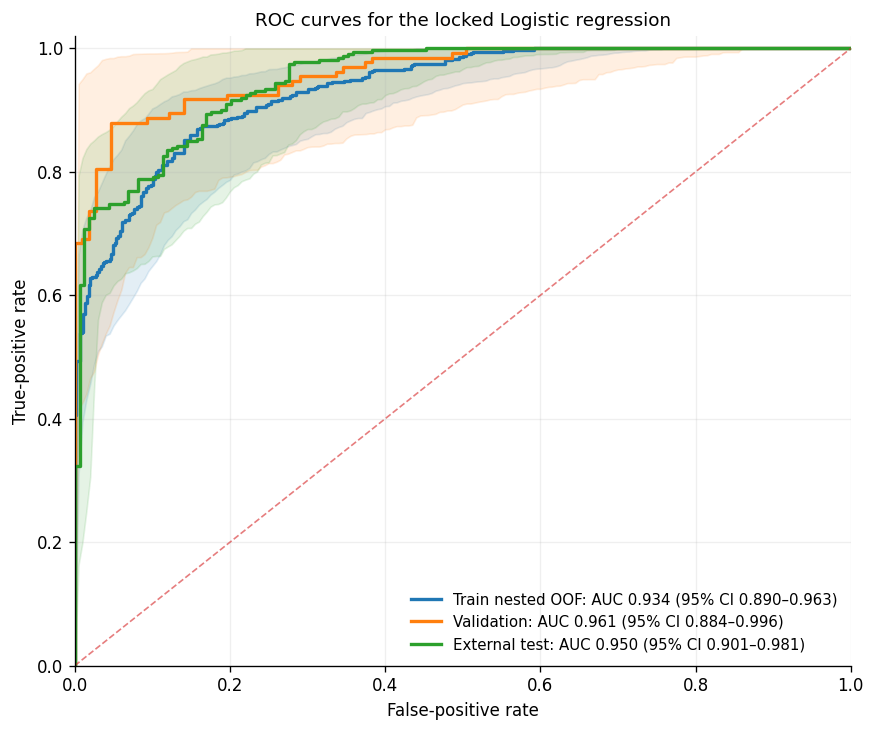

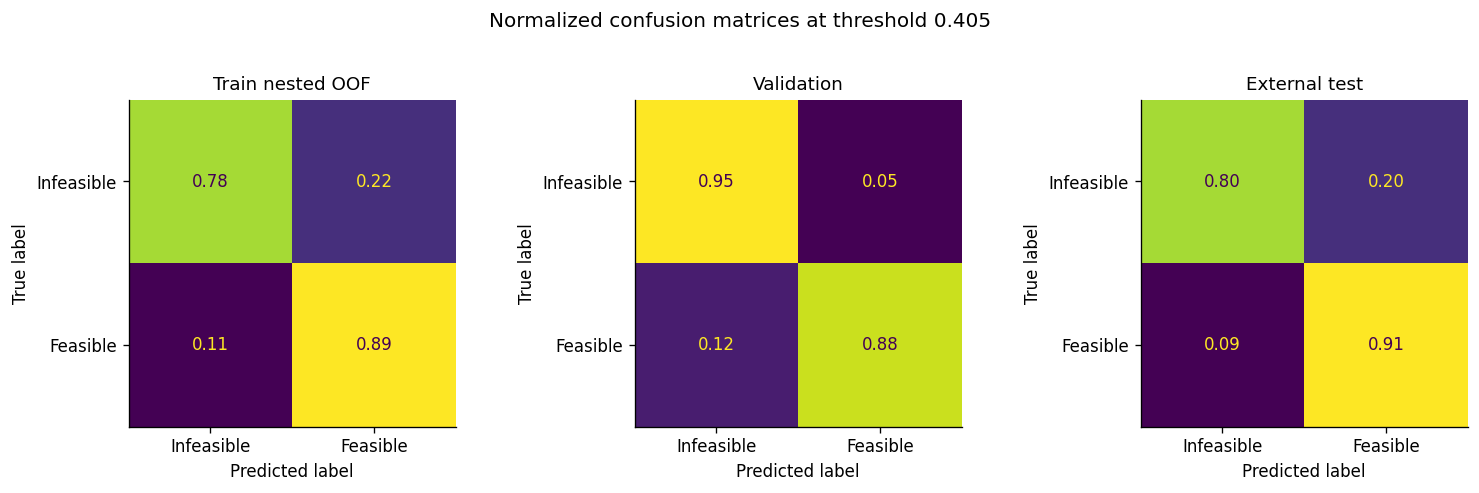

In [15]:
def bootstrap_roc_band(
    y_true: pd.Series | np.ndarray,
    probabilities: np.ndarray,
    groups: pd.Series | np.ndarray,
    n_bootstrap: int,
    seed: int,
    grid_size: int = 201,
) -> dict[str, Any]:
    y_array = np.asarray(y_true, dtype=int)
    probability_array = np.asarray(probabilities, dtype=float)
    fpr_grid = np.linspace(0.0, 1.0, grid_size)

    point_fpr, point_tpr, _ = roc_curve(y_array, probability_array)
    point_auc = roc_auc_score(y_array, probability_array)

    rng = np.random.default_rng(seed)
    interpolated_tprs = []
    auc_values = []
    attempts = 0

    while len(auc_values) < n_bootstrap and attempts < n_bootstrap * 10:
        attempts += 1
        indices = group_bootstrap_indices(groups, rng)
        y_sample = y_array[indices]
        probability_sample = probability_array[indices]
        if np.unique(y_sample).size < 2:
            continue

        fpr, tpr, _ = roc_curve(y_sample, probability_sample)
        interpolated = np.interp(fpr_grid, fpr, tpr)
        interpolated[0] = 0.0
        interpolated[-1] = 1.0
        interpolated_tprs.append(interpolated)
        auc_values.append(roc_auc_score(y_sample, probability_sample))

    tpr_matrix = np.asarray(interpolated_tprs)
    auc_array = np.asarray(auc_values)

    return {
        "point_fpr": point_fpr,
        "point_tpr": point_tpr,
        "point_auc": point_auc,
        "auc_low": np.percentile(auc_array, 2.5),
        "auc_high": np.percentile(auc_array, 97.5),
        "fpr_grid": fpr_grid,
        "tpr_low": np.percentile(tpr_matrix, 2.5, axis=0),
        "tpr_high": np.percentile(tpr_matrix, 97.5, axis=0),
    }


fig, ax = plt.subplots(figsize=(7.4, 6.2))
for split_index, (split_name, (labels, probabilities, groups)) in enumerate(
    evaluation_inputs.items()
):
    roc_result = bootstrap_roc_band(
        labels,
        probabilities,
        groups,
        n_bootstrap=ROC_BOOTSTRAP,
        seed=RANDOM_SEED + 800 + split_index,
    )
    (line,) = ax.plot(
        roc_result["point_fpr"],
        roc_result["point_tpr"],
        linewidth=2,
        label=(
            f"{split_name}: AUC {roc_result['point_auc']:.3f} "
            f"(95% CI {roc_result['auc_low']:.3f}–{roc_result['auc_high']:.3f})"
        ),
    )
    ax.fill_between(
        roc_result["fpr_grid"],
        roc_result["tpr_low"],
        roc_result["tpr_high"],
        alpha=0.12,
        color=line.get_color(),
    )

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, alpha=0.6)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel("False-positive rate")
ax.set_ylabel("True-positive rate")
ax.set_title(f"ROC curves for the locked {BEST_MODEL_NAME}")
ax.grid(alpha=0.2)
ax.legend(loc="lower right", frameon=False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "roc_auc_curves_95ci.pdf", bbox_inches="tight")
fig.savefig(FIGURE_DIR / "roc_auc_curves_95ci.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12.8, 3.9))
for ax, (split_name, (labels, probabilities, _)) in zip(
    axes, evaluation_inputs.items()
):
    predictions = (np.asarray(probabilities) >= OPERATING_THRESHOLD).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        labels,
        predictions,
        labels=[0, 1],
        display_labels=["Infeasible", "Feasible"],
        normalize="true",
        values_format=".2f",
        ax=ax,
        colorbar=False,
    )
    ax.set_title(split_name)

fig.suptitle(
    f"Normalized confusion matrices at threshold {OPERATING_THRESHOLD:.3f}",
    y=1.03,
)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "confusion_matrices.pdf", bbox_inches="tight")
fig.savefig(FIGURE_DIR / "confusion_matrices.png", bbox_inches="tight")
plt.show()

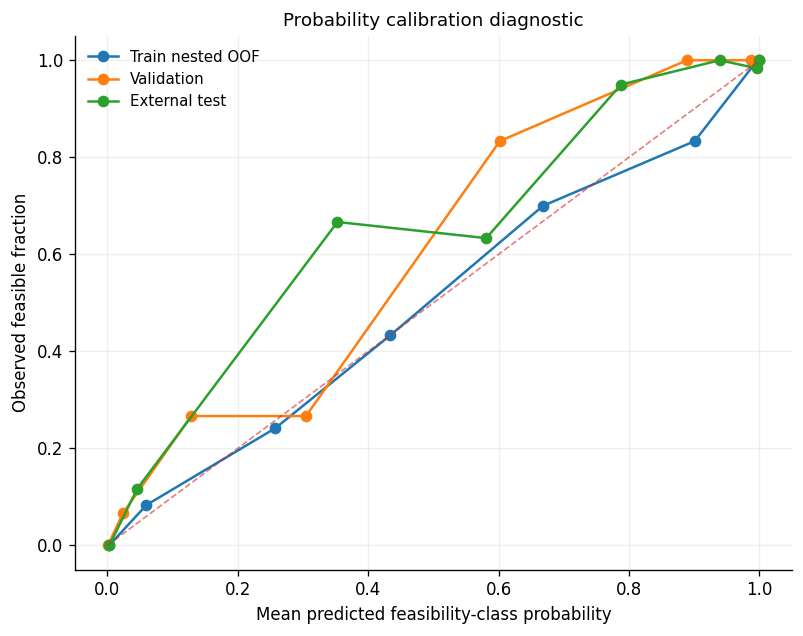

,Split,Brier score,ECE (10 equal-width bins)
0,Train nested OOF,0.104684,0.019348
1,Validation,0.086079,0.079557
2,External test,0.095473,0.081239


In [16]:
def expected_calibration_error(
    y_true: np.ndarray | pd.Series,
    probabilities: np.ndarray,
    n_bins: int = 10,
) -> float:
    y_array = np.asarray(y_true, dtype=int)
    probability_array = np.asarray(probabilities, dtype=float)
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.clip(np.digitize(probability_array, bin_edges[1:-1]), 0, n_bins - 1)

    ece = 0.0
    for bin_id in range(n_bins):
        mask = bin_ids == bin_id
        if not mask.any():
            continue
        ece += mask.mean() * abs(y_array[mask].mean() - probability_array[mask].mean())
    return float(ece)


calibration_rows = []
fig, ax = plt.subplots(figsize=(6.8, 5.4))

for split_name, (labels, probabilities, _) in evaluation_inputs.items():
    observed, predicted = calibration_curve(
        labels,
        probabilities,
        n_bins=8,
        strategy="quantile",
    )
    ax.plot(predicted, observed, marker="o", label=split_name)
    calibration_rows.append(
        {
            "Split": split_name,
            "Brier score": brier_score_loss(labels, probabilities),
            "ECE (10 equal-width bins)": expected_calibration_error(
                labels, probabilities, n_bins=10
            ),
        }
    )

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, alpha=0.6)
ax.set_xlabel("Mean predicted feasibility-class probability")
ax.set_ylabel("Observed feasible fraction")
ax.set_title("Probability calibration diagnostic")
ax.grid(alpha=0.2)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "calibration_curve.pdf", bbox_inches="tight")
fig.savefig(FIGURE_DIR / "calibration_curve.png", bbox_inches="tight")
plt.show()

calibration_summary = pd.DataFrame(calibration_rows)
display(calibration_summary)
calibration_summary.to_csv(
    TABLE_DIR / "calibration_summary.csv", index=False
)

## 14. Route-ranking evaluation with explicit ties, random/oracle baselines, and confidence intervals

In [17]:
def evaluate_route_ranking(
    frame: pd.DataFrame,
    predicted_probabilities: np.ndarray,
) -> tuple[pd.DataFrame, dict[str, float]]:
    ranked = frame.copy().reset_index(drop=True)
    ranked["predicted_feasibility_probability"] = np.asarray(
        predicted_probabilities, dtype=float
    )

    group_rows = []

    for ranking_group, group in ranked.groupby(RANKING_GROUP_COLUMN, sort=False):
        group = group.copy()
        maximum_prediction = group["predicted_feasibility_probability"].max()
        predicted_top_routes = group.loc[
            np.isclose(
                group["predicted_feasibility_probability"], maximum_prediction
            )
        ].copy()

        # Explicit deterministic tie-break: lexicographically smallest route_id.
        selected_row = predicted_top_routes.assign(
            _route_sort_key=predicted_top_routes["route_id"].astype(str)
        ).sort_values("_route_sort_key").iloc[0]

        oracle_success = float(group[PROBABILITY_TARGET].max())
        selected_success = float(selected_row[PROBABILITY_TARGET])
        oracle_mask = np.isclose(group[PROBABILITY_TARGET], oracle_success)
        oracle_route_ids = set(group.loc[oracle_mask, "route_id"].astype(str))

        relevance = group[PROBABILITY_TARGET].to_numpy(dtype=float)
        predicted_scores = group["predicted_feasibility_probability"].to_numpy(
            dtype=float
        )

        if np.isclose(relevance.max(), relevance.min()):
            informative_ndcg = np.nan
            all_group_ndcg_convention = 1.0
        else:
            informative_ndcg = float(
                ndcg_score(relevance.reshape(1, -1), predicted_scores.reshape(1, -1))
            )
            all_group_ndcg_convention = informative_ndcg

        group_rows.append(
            {
                GROUP_COLUMN: str(selected_row[GROUP_COLUMN]),
                RANKING_GROUP_COLUMN: ranking_group,
                "difficulty": str(selected_row["difficulty"]),
                "selected_route_id": str(selected_row["route_id"]),
                "predicted_top_tie_count": len(predicted_top_routes),
                "selected_observed_success_probability": selected_success,
                "oracle_success_probability": oracle_success,
                "regret": oracle_success - selected_success,
                "tie_aware_top1_correct": float(
                    str(selected_row["route_id"]) in oracle_route_ids
                ),
                "selected_route_feasible": float(selected_row[TARGET]),
                "nDCG@4_informative": informative_ndcg,
                "nDCG@4_all_groups_convention": all_group_ndcg_convention,
                "random_top1_expectation": float(oracle_mask.mean()),
                "random_expected_success_probability": float(
                    group[PROBABILITY_TARGET].mean()
                ),
                "random_expected_regret": float(
                    oracle_success - group[PROBABILITY_TARGET].mean()
                ),
                "random_selected_route_feasibility": float(group[TARGET].mean()),
                "oracle_selected_route_feasibility": float(group[TARGET].max()),
            }
        )

    group_results = pd.DataFrame(group_rows)

    summary = {
        "Ranking groups": len(group_results),
        "Tie-aware top-1 accuracy": group_results[
            "tie_aware_top1_correct"
        ].mean(),
        "Random top-1 expectation": group_results[
            "random_top1_expectation"
        ].mean(),
        "Mean regret": group_results["regret"].mean(),
        "Random expected regret": group_results[
            "random_expected_regret"
        ].mean(),
        "Selected-route feasibility rate": group_results[
            "selected_route_feasible"
        ].mean(),
        "Random selected-route feasibility": group_results[
            "random_selected_route_feasibility"
        ].mean(),
        "Oracle selected-route feasibility": group_results[
            "oracle_selected_route_feasibility"
        ].mean(),
        "Mean selected observed success probability": group_results[
            "selected_observed_success_probability"
        ].mean(),
        "Mean nDCG@4 among informative groups": group_results[
            "nDCG@4_informative"
        ].mean(),
        "Informative nDCG groups": group_results[
            "nDCG@4_informative"
        ].notna().sum(),
        "Mean predicted-top tie count": group_results[
            "predicted_top_tie_count"
        ].mean(),
    }

    return group_results, summary


validation_ranking_groups, validation_ranking_summary = evaluate_route_ranking(
    validation_df, validation_probability
)
test_ranking_groups, test_ranking_summary = evaluate_route_ranking(
    test_df, test_probability
)

ranking_summary = pd.DataFrame(
    [
        {"Split": "Validation", **validation_ranking_summary},
        {"Split": "External test", **test_ranking_summary},
    ]
)
display(ranking_summary)

ranking_summary.to_csv(TABLE_DIR / "route_ranking_summary.csv", index=False)
validation_ranking_groups.to_csv(
    TABLE_DIR / "validation_route_ranking_groups.csv", index=False
)
test_ranking_groups.to_csv(
    TABLE_DIR / "external_test_route_ranking_groups.csv", index=False
)

,Split,Ranking groups,Tie-aware top-1 accuracy,Random top-1 expectation,Mean regret,Random expected regret,Selected-route feasibility rate,Random selected-route feasibility,Oracle selected-route feasibility,Mean selected observed success probability,Mean nDCG@4 among informative groups,Informative nDCG groups,Mean predicted-top tie count
0,Validation,60,0.85,0.591667,0.033333,0.120000,0.666667,0.554167,0.716667,0.630000,0.913905,40,1.466667
1,External test,120,0.70,0.633333,0.070000,0.130833,0.766667,0.668750,0.816667,0.691667,0.942295,69,1.400000


In [18]:
RANKING_METRIC_COLUMNS = {
    "Tie-aware top-1 accuracy": "tie_aware_top1_correct",
    "Random top-1 expectation": "random_top1_expectation",
    "Mean regret": "regret",
    "Random expected regret": "random_expected_regret",
    "Selected-route feasibility rate": "selected_route_feasible",
    "Random selected-route feasibility": "random_selected_route_feasibility",
    "Oracle selected-route feasibility": "oracle_selected_route_feasibility",
    "Mean selected observed success probability": "selected_observed_success_probability",
    "Mean nDCG@4 among informative groups": "nDCG@4_informative",
}


def ranking_bootstrap_intervals(
    group_results: pd.DataFrame,
    n_bootstrap: int,
    seed: int,
) -> pd.DataFrame:
    point_estimates = {
        metric_name: group_results[column_name].mean()
        for metric_name, column_name in RANKING_METRIC_COLUMNS.items()
    }

    rng = np.random.default_rng(seed)
    unique_scenarios = group_results[GROUP_COLUMN].unique()
    bootstrap_values = {metric_name: [] for metric_name in point_estimates}

    for _ in range(n_bootstrap):
        sampled_scenarios = rng.choice(
            unique_scenarios, size=len(unique_scenarios), replace=True
        )
        sampled = pd.concat(
            [
                group_results.loc[group_results[GROUP_COLUMN] == scenario]
                for scenario in sampled_scenarios
            ],
            ignore_index=True,
        )

        for metric_name, column_name in RANKING_METRIC_COLUMNS.items():
            bootstrap_values[metric_name].append(sampled[column_name].mean())

    rows = []
    for metric_name, estimate in point_estimates.items():
        values = np.asarray(bootstrap_values[metric_name], dtype=float)
        finite = values[np.isfinite(values)]
        rows.append(
            {
                "Metric": metric_name,
                "Estimate": estimate,
                "95% CI low": np.percentile(finite, 2.5),
                "95% CI high": np.percentile(finite, 97.5),
                "Valid bootstrap replicates": len(finite),
            }
        )

    return pd.DataFrame(rows)


ranking_ci_tables = []
for split_index, (split_name, group_results) in enumerate(
    {
        "Validation": validation_ranking_groups,
        "External test": test_ranking_groups,
    }.items()
):
    table = ranking_bootstrap_intervals(
        group_results,
        n_bootstrap=RANKING_BOOTSTRAP,
        seed=RANDOM_SEED + 900 + split_index,
    )
    table.insert(0, "Split", split_name)
    ranking_ci_tables.append(table)

ranking_metrics_with_ci = pd.concat(ranking_ci_tables, ignore_index=True)
display(ranking_metrics_with_ci)
ranking_metrics_with_ci.to_csv(
    TABLE_DIR / "route_ranking_metrics_scenario_bootstrap_95ci.csv", index=False
)

ranking_difficulty_rows = []
for split_name, group_results in {
    "Validation": validation_ranking_groups,
    "External test": test_ranking_groups,
}.items():
    for difficulty, subset in group_results.groupby(
        group_results["difficulty"].str.lower()
    ):
        ranking_difficulty_rows.append(
            {
                "Split": split_name,
                "Difficulty": difficulty,
                "Ranking groups": len(subset),
                "Tie-aware top-1 accuracy": subset[
                    "tie_aware_top1_correct"
                ].mean(),
                "Random top-1 expectation": subset[
                    "random_top1_expectation"
                ].mean(),
                "Mean regret": subset["regret"].mean(),
                "Random expected regret": subset[
                    "random_expected_regret"
                ].mean(),
                "Selected-route feasibility rate": subset[
                    "selected_route_feasible"
                ].mean(),
                "Random selected-route feasibility": subset[
                    "random_selected_route_feasibility"
                ].mean(),
                "Mean nDCG@4 among informative groups": subset[
                    "nDCG@4_informative"
                ].mean(),
            }
        )

ranking_by_difficulty = pd.DataFrame(ranking_difficulty_rows)
display(ranking_by_difficulty)
ranking_by_difficulty.to_csv(
    TABLE_DIR / "route_ranking_by_difficulty.csv", index=False
)

,Split,Metric,Estimate,95% CI low,95% CI high,Valid bootstrap replicates
0,Validation,Tie-aware top-1 accuracy,0.850000,0.766667,0.933333,2000
1,Validation,Random top-1 expectation,0.591667,0.462396,0.733333,2000
2,Validation,Mean regret,0.033333,0.013333,0.053333,2000
3,Validation,Random expected regret,0.120000,0.075812,0.162500,2000
4,Validation,Selected-route feasibility rate,0.666667,0.450000,0.866667,2000
5,Validation,Random selected-route feasibility,0.554167,0.341667,0.750104,2000
6,Validation,Oracle selected-route feasibility,0.716667,0.483333,0.916667,2000
7,Validation,Mean selected observed success probability,0.630000,0.440000,0.796750,2000
8,Validation,Mean nDCG@4 among informative groups,0.913905,0.839458,0.971678,2000
9,External test,Tie-aware top-1 accuracy,0.700000,0.591667,0.816667,2000


,Split,Difficulty,Ranking groups,Tie-aware top-1 accuracy,Random top-1 expectation,Mean regret,Random expected regret,Selected-route feasibility rate,Random selected-route feasibility,Mean nDCG@4 among informative groups
0,Validation,easy,12,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,NaN
1,Validation,hard,12,0.666667,0.625000,0.066667,0.079167,0.000000,0.000000,0.677893
2,Validation,moderate,36,0.861111,0.444444,0.033333,0.173611,0.777778,0.590278,0.963969
3,External test,easy,24,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,NaN
4,External test,hard,24,0.791667,0.687500,0.041667,0.095833,0.083333,0.041667,0.883397
5,External test,moderate,72,0.569444,0.493056,0.102778,0.186111,0.916667,0.767361,0.953466


## 15. Deterministic routing-policy baselines

This section evaluates the learned route-selection policy against four pre-routing baselines and an unattainable oracle upper bound:

- uniform random route selection, reported as an exact expectation rather than one noisy random draw;
- minimum-hop routing;
- minimum total fibre-loss routing;
- maximum bottleneck-link success routing;
- the learned classifier score;
- the oracle route with the highest observed simulation success probability.

These routing policies are evaluated only after the classifier, its hyperparameters, and the operating threshold have been frozen. They do not participate in classifier training or model selection. All deterministic tie-breakers use only pre-routing information.

In [19]:
ROUTING_POLICY_ORDER = [
    "Random route",
    "Minimum hop",
    "Minimum fibre loss",
    "Maximum bottleneck success",
    "Learned model",
    "Oracle",
]


def select_route_for_policy(
    group: pd.DataFrame,
    method: str,
    probability_column: str,
) -> pd.Series:
    """
    Select one route from a ranking group using an explicit,
    reproducible routing policy.

    All heuristic tie-breakers use only pre-routing variables.
    The learned policy uses the same route-id tie-break convention
    as the main route-ranking evaluation above.
    """

    candidates = group.copy()
    candidates["_route_sort_key"] = candidates["route_id"].astype(str)

    if method == "Minimum hop":
        sort_columns = [
            "hop_count",
            "total_fibre_loss_db",
            "bottleneck_link_success_estimate",
            "_route_sort_key",
        ]
        ascending = [True, True, False, True]

    elif method == "Minimum fibre loss":
        sort_columns = [
            "total_fibre_loss_db",
            "bottleneck_link_success_estimate",
            "hop_count",
            "_route_sort_key",
        ]
        ascending = [True, False, True, True]

    elif method == "Maximum bottleneck success":
        sort_columns = [
            "bottleneck_link_success_estimate",
            "total_fibre_loss_db",
            "hop_count",
            "_route_sort_key",
        ]
        ascending = [False, True, True, True]

    elif method == "Learned model":
        sort_columns = [
            probability_column,
            "_route_sort_key",
        ]
        ascending = [False, True]

    elif method == "Oracle":
        sort_columns = [
            PROBABILITY_TARGET,
            "_route_sort_key",
        ]
        ascending = [False, True]

    else:
        raise ValueError(f"Unknown routing policy: {method}")

    return (
        candidates.sort_values(
            sort_columns,
            ascending=ascending,
            kind="mergesort",
        )
        .iloc[0]
    )


def evaluate_routing_policy_baselines(
    frame: pd.DataFrame,
    learned_probabilities: np.ndarray,
    split_name: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Compare the learned route-selection policy with deterministic,
    random, and oracle policies.

    Random-route quantities are exact expectations under uniform
    route selection within each ranking group.
    """

    ranked = frame.copy().reset_index(drop=True)
    learned_probabilities = np.asarray(learned_probabilities, dtype=float)

    if len(ranked) != len(learned_probabilities):
        raise ValueError(
            "The number of learned probabilities does not match "
            "the number of route records."
        )

    if not np.isfinite(learned_probabilities).all():
        raise ValueError("Learned probabilities contain non-finite values.")

    probability_column = "predicted_feasibility_class_probability"
    ranked[probability_column] = learned_probabilities

    required_columns = {
        GROUP_COLUMN,
        RANKING_GROUP_COLUMN,
        "route_id",
        "difficulty",
        TARGET,
        PROBABILITY_TARGET,
        "hop_count",
        "total_fibre_loss_db",
        "bottleneck_link_success_estimate",
    }

    missing_columns = sorted(required_columns.difference(ranked.columns))
    if missing_columns:
        raise ValueError(f"Missing routing-policy columns: {missing_columns}")

    group_rows: list[dict[str, Any]] = []

    for ranking_group, group in ranked.groupby(
        RANKING_GROUP_COLUMN,
        sort=False,
    ):
        group = group.copy()

        if group[GROUP_COLUMN].nunique() != 1:
            raise ValueError(
                f"Ranking group {ranking_group} belongs to multiple scenarios."
            )

        if group["difficulty"].nunique() != 1:
            raise ValueError(
                f"Ranking group {ranking_group} has inconsistent difficulty labels."
            )

        scenario_group = str(group[GROUP_COLUMN].iloc[0])
        difficulty = str(group["difficulty"].iloc[0])

        oracle_success = float(group[PROBABILITY_TARGET].max())
        oracle_mask = np.isclose(
            group[PROBABILITY_TARGET].to_numpy(dtype=float),
            oracle_success,
        )
        number_of_routes = len(group)
        number_of_oracle_best_routes = int(oracle_mask.sum())

        common = {
            "Split": split_name,
            GROUP_COLUMN: scenario_group,
            RANKING_GROUP_COLUMN: ranking_group,
            "difficulty": difficulty,
            "number_of_routes": number_of_routes,
            "number_of_oracle_best_routes": number_of_oracle_best_routes,
            "oracle_success_probability": oracle_success,
        }

        # Exact expectation for a uniformly random route.
        random_expected_success = float(group[PROBABILITY_TARGET].mean())
        random_expected_feasibility = float(group[TARGET].mean())
        random_expected_top1 = (
            number_of_oracle_best_routes / number_of_routes
        )

        group_rows.append(
            {
                **common,
                "Method": "Random route",
                "selected_route_id": "Expected uniform random route",
                "selected_observed_success_probability": random_expected_success,
                "regret": oracle_success - random_expected_success,
                "tie_aware_top1_correct": random_expected_top1,
                "selected_route_feasible": random_expected_feasibility,
                "predicted_top_tie_count": np.nan,
            }
        )

        for method in [
            "Minimum hop",
            "Minimum fibre loss",
            "Maximum bottleneck success",
            "Learned model",
            "Oracle",
        ]:
            selected_row = select_route_for_policy(
                group=group,
                method=method,
                probability_column=probability_column,
            )

            selected_success = float(selected_row[PROBABILITY_TARGET])
            selected_is_oracle_best = float(
                np.isclose(selected_success, oracle_success)
            )

            if method == "Learned model":
                maximum_prediction = float(group[probability_column].max())
                predicted_top_tie_count = int(
                    np.isclose(
                        group[probability_column].to_numpy(dtype=float),
                        maximum_prediction,
                    ).sum()
                )
            else:
                predicted_top_tie_count = np.nan

            group_rows.append(
                {
                    **common,
                    "Method": method,
                    "selected_route_id": str(selected_row["route_id"]),
                    "selected_observed_success_probability": selected_success,
                    "regret": oracle_success - selected_success,
                    "tie_aware_top1_correct": selected_is_oracle_best,
                    "selected_route_feasible": float(selected_row[TARGET]),
                    "predicted_top_tie_count": predicted_top_tie_count,
                }
            )

    group_results = pd.DataFrame(group_rows)

    summary = (
        group_results.groupby(
            ["Split", "Method"],
            as_index=False,
            observed=True,
        )
        .agg(
            ranking_groups=(RANKING_GROUP_COLUMN, "nunique"),
            mean_selected_success=(
                "selected_observed_success_probability",
                "mean",
            ),
            mean_regret=("regret", "mean"),
            feasible_selected_rate=("selected_route_feasible", "mean"),
            tie_aware_top1_accuracy=("tie_aware_top1_correct", "mean"),
        )
    )

    random_row = summary.loc[summary["Method"] == "Random route"].iloc[0]
    random_regret = float(random_row["mean_regret"])
    random_feasibility = float(random_row["feasible_selected_rate"])
    random_top1 = float(random_row["tie_aware_top1_accuracy"])

    summary["regret_reduction_vs_random_percent"] = np.where(
        random_regret > 0,
        100.0 * (random_regret - summary["mean_regret"]) / random_regret,
        np.nan,
    )
    summary["feasible_selection_gain_vs_random_pp"] = (
        100.0 * (summary["feasible_selected_rate"] - random_feasibility)
    )
    summary["top1_gain_vs_random_pp"] = (
        100.0 * (summary["tie_aware_top1_accuracy"] - random_top1)
    )

    summary["Method"] = pd.Categorical(
        summary["Method"],
        categories=ROUTING_POLICY_ORDER,
        ordered=True,
    )

    summary = (
        summary.sort_values("Method")
        .reset_index(drop=True)
    )

    return group_results, summary


In [20]:
validation_policy_groups, validation_policy_summary = (
    evaluate_routing_policy_baselines(
        frame=validation_df,
        learned_probabilities=validation_probability,
        split_name="Validation",
    )
)

external_policy_groups, external_policy_summary = (
    evaluate_routing_policy_baselines(
        frame=test_df,
        learned_probabilities=test_probability,
        split_name="External test",
    )
)

routing_policy_summary = pd.concat(
    [
        validation_policy_summary,
        external_policy_summary,
    ],
    ignore_index=True,
)

display(routing_policy_summary)

validation_policy_groups.to_csv(
    TABLE_DIR / "validation_routing_policy_group_results.csv",
    index=False,
)
external_policy_groups.to_csv(
    TABLE_DIR / "external_routing_policy_group_results.csv",
    index=False,
)
routing_policy_summary.to_csv(
    TABLE_DIR / "routing_policy_baseline_summary.csv",
    index=False,
)

routing_policy_difficulty_summary = (
    pd.concat(
        [
            validation_policy_groups,
            external_policy_groups,
        ],
        ignore_index=True,
    )
    .groupby(
        ["Split", "difficulty", "Method"],
        as_index=False,
        observed=True,
    )
    .agg(
        ranking_groups=(RANKING_GROUP_COLUMN, "nunique"),
        mean_regret=("regret", "mean"),
        feasible_selected_rate=("selected_route_feasible", "mean"),
        tie_aware_top1_accuracy=("tie_aware_top1_correct", "mean"),
        mean_selected_success=(
            "selected_observed_success_probability",
            "mean",
        ),
    )
)

routing_policy_difficulty_summary["Method"] = pd.Categorical(
    routing_policy_difficulty_summary["Method"],
    categories=ROUTING_POLICY_ORDER,
    ordered=True,
)

routing_policy_difficulty_summary = (
    routing_policy_difficulty_summary.sort_values(
        ["Split", "difficulty", "Method"]
    )
    .reset_index(drop=True)
)

display(routing_policy_difficulty_summary)

routing_policy_difficulty_summary.to_csv(
    TABLE_DIR / "routing_policy_baselines_by_difficulty.csv",
    index=False,
)


,Split,Method,ranking_groups,mean_selected_success,mean_regret,feasible_selected_rate,tie_aware_top1_accuracy,regret_reduction_vs_random_percent,feasible_selection_gain_vs_random_pp,top1_gain_vs_random_pp
0,Validation,Random route,60,0.543333,0.120000,0.554167,0.591667,0.000000,0.000000,0.000000
1,Validation,Minimum hop,60,0.596667,0.066667,0.616667,0.783333,44.444444,6.250000,19.166667
2,Validation,Minimum fibre loss,60,0.633333,0.030000,0.666667,0.866667,75.000000,11.250000,27.500000
3,Validation,Maximum bottleneck success,60,0.613333,0.050000,0.616667,0.833333,58.333333,6.250000,24.166667
4,Validation,Learned model,60,0.630000,0.033333,0.666667,0.850000,72.222222,11.250000,25.833333
5,Validation,Oracle,60,0.663333,0.000000,0.716667,1.000000,100.000000,16.250000,40.833333
6,External test,Random route,120,0.630833,0.130833,0.668750,0.633333,0.000000,0.000000,0.000000
7,External test,Minimum hop,120,0.693333,0.068333,0.766667,0.716667,47.770701,9.791667,8.333333
8,External test,Minimum fibre loss,120,0.688333,0.073333,0.775000,0.700000,43.949045,10.625000,6.666667
9,External test,Maximum bottleneck success,120,0.683333,0.078333,0.741667,0.766667,40.127389,7.291667,13.333333


,Split,difficulty,Method,ranking_groups,mean_regret,feasible_selected_rate,tie_aware_top1_accuracy,mean_selected_success
0,External test,easy,Random route,24,0.000000,1.000000,1.000000,1.000000
1,External test,easy,Minimum hop,24,0.000000,1.000000,1.000000,1.000000
2,External test,easy,Minimum fibre loss,24,0.000000,1.000000,1.000000,1.000000
3,External test,easy,Maximum bottleneck success,24,0.000000,1.000000,1.000000,1.000000
4,External test,easy,Learned model,24,0.000000,1.000000,1.000000,1.000000
5,External test,easy,Oracle,24,0.000000,1.000000,1.000000,1.000000
6,External test,hard,Random route,24,0.095833,0.041667,0.687500,0.070833
7,External test,hard,Minimum hop,24,0.025000,0.083333,0.875000,0.141667
8,External test,hard,Minimum fibre loss,24,0.050000,0.125000,0.791667,0.116667
9,External test,hard,Maximum bottleneck success,24,0.083333,0.125000,0.666667,0.083333


In [21]:
ROUTING_POLICY_METRICS = {
    "Mean regret": "regret",
    "Feasible selected rate": "selected_route_feasible",
    "Tie-aware top-1 accuracy": "tie_aware_top1_correct",
    "Mean selected success": "selected_observed_success_probability",
}


def routing_policy_bootstrap_intervals(
    group_results: pd.DataFrame,
    n_bootstrap: int,
    seed: int,
) -> pd.DataFrame:
    """
    Compute percentile 95% confidence intervals by resampling
    complete simulation scenarios with replacement.
    """

    unique_scenarios = group_results[GROUP_COLUMN].drop_duplicates().to_numpy()
    rng = np.random.default_rng(seed)

    bootstrap_records: list[dict[str, Any]] = []

    for bootstrap_index in range(n_bootstrap):
        sampled_scenarios = rng.choice(
            unique_scenarios,
            size=len(unique_scenarios),
            replace=True,
        )

        sampled_parts = []
        for draw_number, scenario_id in enumerate(sampled_scenarios):
            part = group_results.loc[
                group_results[GROUP_COLUMN] == scenario_id
            ].copy()
            part["_bootstrap_draw"] = draw_number
            sampled_parts.append(part)

        sampled = pd.concat(sampled_parts, ignore_index=True)

        for method, method_frame in sampled.groupby(
            "Method",
            observed=True,
        ):
            for metric_name, column_name in ROUTING_POLICY_METRICS.items():
                bootstrap_records.append(
                    {
                        "Bootstrap": bootstrap_index,
                        "Method": str(method),
                        "Metric": metric_name,
                        "Value": float(method_frame[column_name].mean()),
                    }
                )

    bootstrap_frame = pd.DataFrame(bootstrap_records)

    point_rows: list[dict[str, Any]] = []

    for method, method_frame in group_results.groupby(
        "Method",
        observed=True,
    ):
        for metric_name, column_name in ROUTING_POLICY_METRICS.items():
            bootstrap_values = bootstrap_frame.loc[
                (bootstrap_frame["Method"] == str(method))
                & (bootstrap_frame["Metric"] == metric_name),
                "Value",
            ].to_numpy(dtype=float)

            finite_values = bootstrap_values[np.isfinite(bootstrap_values)]

            point_rows.append(
                {
                    "Method": str(method),
                    "Metric": metric_name,
                    "Estimate": float(method_frame[column_name].mean()),
                    "95% CI low": float(np.percentile(finite_values, 2.5)),
                    "95% CI high": float(np.percentile(finite_values, 97.5)),
                    "Valid bootstrap replicates": len(finite_values),
                }
            )

    result = pd.DataFrame(point_rows)
    result["Method"] = pd.Categorical(
        result["Method"],
        categories=ROUTING_POLICY_ORDER,
        ordered=True,
    )

    return (
        result.sort_values(["Metric", "Method"])
        .reset_index(drop=True)
    )


validation_policy_ci = routing_policy_bootstrap_intervals(
    group_results=validation_policy_groups,
    n_bootstrap=RANKING_BOOTSTRAP,
    seed=RANDOM_SEED + 1200,
)

external_policy_ci = routing_policy_bootstrap_intervals(
    group_results=external_policy_groups,
    n_bootstrap=RANKING_BOOTSTRAP,
    seed=RANDOM_SEED + 1201,
)

routing_policy_metrics_with_ci = pd.concat(
    [
        validation_policy_ci.assign(Split="Validation"),
        external_policy_ci.assign(Split="External test"),
    ],
    ignore_index=True,
)

routing_policy_metrics_with_ci = routing_policy_metrics_with_ci[
    [
        "Split",
        "Method",
        "Metric",
        "Estimate",
        "95% CI low",
        "95% CI high",
        "Valid bootstrap replicates",
    ]
]

display(routing_policy_metrics_with_ci)

routing_policy_metrics_with_ci.to_csv(
    TABLE_DIR / "routing_policy_metrics_scenario_bootstrap_95ci.csv",
    index=False,
)


,Split,Method,Metric,Estimate,95% CI low,95% CI high,Valid bootstrap replicates
0,Validation,Random route,Feasible selected rate,0.554167,0.350000,0.762500,2000
1,Validation,Minimum hop,Feasible selected rate,0.616667,0.399583,0.816667,2000
2,Validation,Minimum fibre loss,Feasible selected rate,0.666667,0.450000,0.883333,2000
3,Validation,Maximum bottleneck success,Feasible selected rate,0.616667,0.400000,0.816667,2000
4,Validation,Learned model,Feasible selected rate,0.666667,0.450000,0.866667,2000
5,Validation,Oracle,Feasible selected rate,0.716667,0.466667,0.933333,2000
6,Validation,Random route,Mean regret,0.120000,0.075833,0.164167,2000
7,Validation,Minimum hop,Mean regret,0.066667,0.033333,0.110000,2000
8,Validation,Minimum fibre loss,Mean regret,0.030000,0.010000,0.050000,2000
9,Validation,Maximum bottleneck success,Mean regret,0.050000,0.016667,0.086667,2000


In [22]:
def paired_policy_difference_intervals(
    group_results: pd.DataFrame,
    reference_method: str,
    comparator_methods: list[str],
    n_bootstrap: int,
    seed: int,
) -> pd.DataFrame:
    """
    Scenario-bootstrap paired differences between the learned policy
    and each non-oracle routing baseline.

    Positive regret reduction, feasible-selection gain, and top-1 gain
    indicate that the learned policy is better.
    """

    wide = group_results.pivot(
        index=[
            GROUP_COLUMN,
            RANKING_GROUP_COLUMN,
            "difficulty",
        ],
        columns="Method",
        values=[
            "regret",
            "selected_route_feasible",
            "tie_aware_top1_correct",
        ],
    )

    required_methods = [reference_method, *comparator_methods]
    available_methods = set(
        wide.columns.get_level_values(1)
    )
    missing = sorted(set(required_methods).difference(available_methods))
    if missing:
        raise ValueError(f"Missing routing methods for paired comparison: {missing}")

    scenario_ids = wide.index.get_level_values(GROUP_COLUMN).unique().to_numpy()
    rng = np.random.default_rng(seed)

    point_rows: list[dict[str, Any]] = []

    for comparator in comparator_methods:
        per_group = pd.DataFrame(
            {
                GROUP_COLUMN: wide.index.get_level_values(GROUP_COLUMN),
                "Regret reduction": (
                    wide[("regret", comparator)].to_numpy(dtype=float)
                    - wide[("regret", reference_method)].to_numpy(dtype=float)
                ),
                "Feasible-selection gain": (
                    wide[("selected_route_feasible", reference_method)]
                    .to_numpy(dtype=float)
                    - wide[("selected_route_feasible", comparator)]
                    .to_numpy(dtype=float)
                ),
                "Top-1 gain": (
                    wide[("tie_aware_top1_correct", reference_method)]
                    .to_numpy(dtype=float)
                    - wide[("tie_aware_top1_correct", comparator)]
                    .to_numpy(dtype=float)
                ),
            }
        )

        bootstrap_values = {
            "Regret reduction": [],
            "Feasible-selection gain": [],
            "Top-1 gain": [],
        }

        for _ in range(n_bootstrap):
            sampled_scenarios = rng.choice(
                scenario_ids,
                size=len(scenario_ids),
                replace=True,
            )

            sampled = pd.concat(
                [
                    per_group.loc[per_group[GROUP_COLUMN] == scenario]
                    for scenario in sampled_scenarios
                ],
                ignore_index=True,
            )

            for metric_name in bootstrap_values:
                bootstrap_values[metric_name].append(
                    float(sampled[metric_name].mean())
                )

        for metric_name, values in bootstrap_values.items():
            value_array = np.asarray(values, dtype=float)
            point_rows.append(
                {
                    "Reference method": reference_method,
                    "Comparator": comparator,
                    "Metric": metric_name,
                    "Estimate": float(per_group[metric_name].mean()),
                    "95% CI low": float(np.percentile(value_array, 2.5)),
                    "95% CI high": float(np.percentile(value_array, 97.5)),
                    "Bootstrap replicates": len(value_array),
                }
            )

    return pd.DataFrame(point_rows)


learned_policy_paired_differences = paired_policy_difference_intervals(
    group_results=external_policy_groups,
    reference_method="Learned model",
    comparator_methods=[
        "Random route",
        "Minimum hop",
        "Minimum fibre loss",
        "Maximum bottleneck success",
    ],
    n_bootstrap=RANKING_BOOTSTRAP,
    seed=RANDOM_SEED + 1300,
)

display(learned_policy_paired_differences)

learned_policy_paired_differences.to_csv(
    TABLE_DIR / "learned_vs_routing_baselines_paired_95ci.csv",
    index=False,
)


,Reference method,Comparator,Metric,Estimate,95% CI low,95% CI high,Bootstrap replicates
0,Learned model,Random route,Regret reduction,0.060833,0.030823,0.094583,2000
1,Learned model,Random route,Feasible-selection gain,0.097917,0.047917,0.154167,2000
2,Learned model,Random route,Top-1 gain,0.066667,0.004167,0.139635,2000
3,Learned model,Minimum hop,Regret reduction,-0.001667,-0.011667,0.008333,2000
4,Learned model,Minimum hop,Feasible-selection gain,0.000000,0.000000,0.000000,2000
5,Learned model,Minimum hop,Top-1 gain,-0.016667,-0.058333,0.016667,2000
6,Learned model,Minimum fibre loss,Regret reduction,0.003333,-0.003333,0.013333,2000
7,Learned model,Minimum fibre loss,Feasible-selection gain,-0.008333,-0.025000,0.000000,2000
8,Learned model,Minimum fibre loss,Top-1 gain,0.000000,-0.025000,0.025000,2000
9,Learned model,Maximum bottleneck success,Regret reduction,0.008333,-0.031667,0.048333,2000


,Routing method,Mean regret,Feasible selected,Tie-aware top-1,Mean selected success,Regret reduction vs random (%)
0,Random route,0.130833,0.668750,0.633333,0.630833,0.000000
1,Minimum hop,0.068333,0.766667,0.716667,0.693333,47.770701
2,Minimum fibre loss,0.073333,0.775000,0.700000,0.688333,43.949045
3,Maximum bottleneck success,0.078333,0.741667,0.766667,0.683333,40.127389
4,Learned model,0.070000,0.766667,0.700000,0.691667,46.496815
5,Oracle,0.000000,0.816667,1.000000,0.761667,100.000000


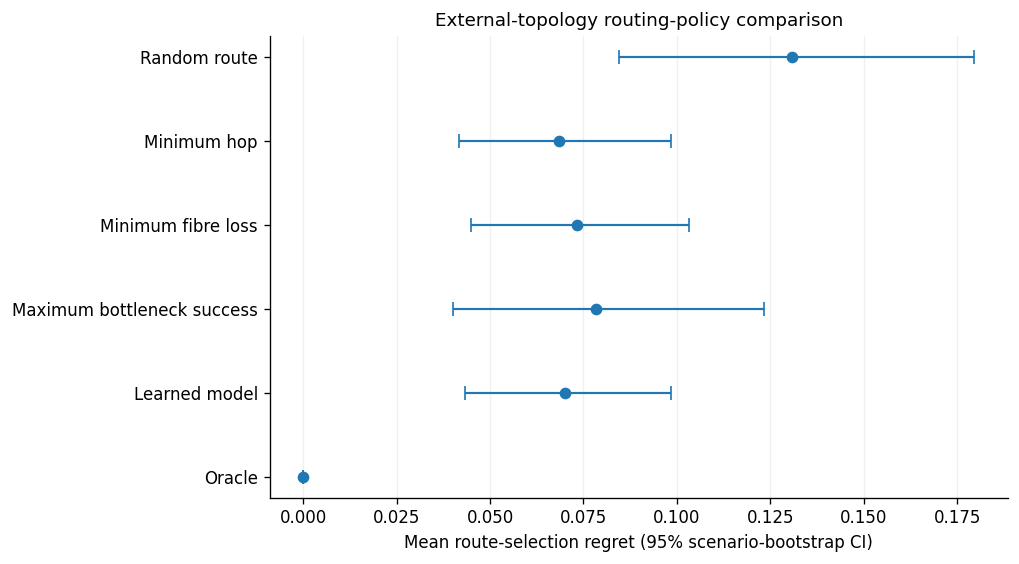

In [23]:
external_paper_routing_table = external_policy_summary[
    [
        "Method",
        "mean_regret",
        "feasible_selected_rate",
        "tie_aware_top1_accuracy",
        "mean_selected_success",
        "regret_reduction_vs_random_percent",
    ]
].copy()

external_paper_routing_table = external_paper_routing_table.rename(
    columns={
        "Method": "Routing method",
        "mean_regret": "Mean regret",
        "feasible_selected_rate": "Feasible selected",
        "tie_aware_top1_accuracy": "Tie-aware top-1",
        "mean_selected_success": "Mean selected success",
        "regret_reduction_vs_random_percent": (
            "Regret reduction vs random (%)"
        ),
    }
)

display(external_paper_routing_table)

external_paper_routing_table.to_csv(
    TABLE_DIR / "paper_external_routing_baseline_table.csv",
    index=False,
)

external_regret_ci = external_policy_ci.loc[
    external_policy_ci["Metric"] == "Mean regret"
].copy()

external_regret_ci["Method"] = pd.Categorical(
    external_regret_ci["Method"],
    categories=ROUTING_POLICY_ORDER,
    ordered=True,
)

external_regret_ci = (
    external_regret_ci.sort_values("Method")
    .reset_index(drop=True)
)

figure_means = external_regret_ci["Estimate"].to_numpy(dtype=float)
figure_low_error = (
    figure_means
    - external_regret_ci["95% CI low"].to_numpy(dtype=float)
)
figure_high_error = (
    external_regret_ci["95% CI high"].to_numpy(dtype=float)
    - figure_means
)

fig, ax = plt.subplots(figsize=(8.6, 4.8))

ax.errorbar(
    figure_means,
    np.arange(len(external_regret_ci)),
    xerr=np.vstack([figure_low_error, figure_high_error]),
    fmt="o",
    capsize=4,
    linewidth=1.3,
)

ax.set_yticks(
    np.arange(len(external_regret_ci)),
    external_regret_ci["Method"].astype(str),
)
ax.invert_yaxis()
ax.set_xlabel("Mean route-selection regret (95% scenario-bootstrap CI)")
ax.set_title("External-topology routing-policy comparison")
ax.grid(axis="x", alpha=0.2)

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "routing_policy_mean_regret_95ci.pdf",
    bbox_inches="tight",
)
fig.savefig(
    FIGURE_DIR / "routing_policy_mean_regret_95ci.png",
    bbox_inches="tight",
)
plt.show()


## 16. Validation permutation importance

,Feature,Mean validation ROC-AUC decrease,SD validation ROC-AUC decrease
6,deadline_margin_ms,0.251888,0.033906
9,effective_efficiency,0.051600,0.011288
5,fidelity_margin_estimate,0.016295,0.006190
1,total_fibre_loss_db,0.016167,0.004575
0,hop_count,0.005839,0.002410
2,maximum_link_loss_db,0.005603,0.002467
4,min_memory_requirement_margin,0.004264,0.001101
7,route_degraded_link_fraction,0.002694,0.001408
10,coherence_time_s,0.000509,0.002549
3,bottleneck_link_success_estimate,0.000193,0.002340


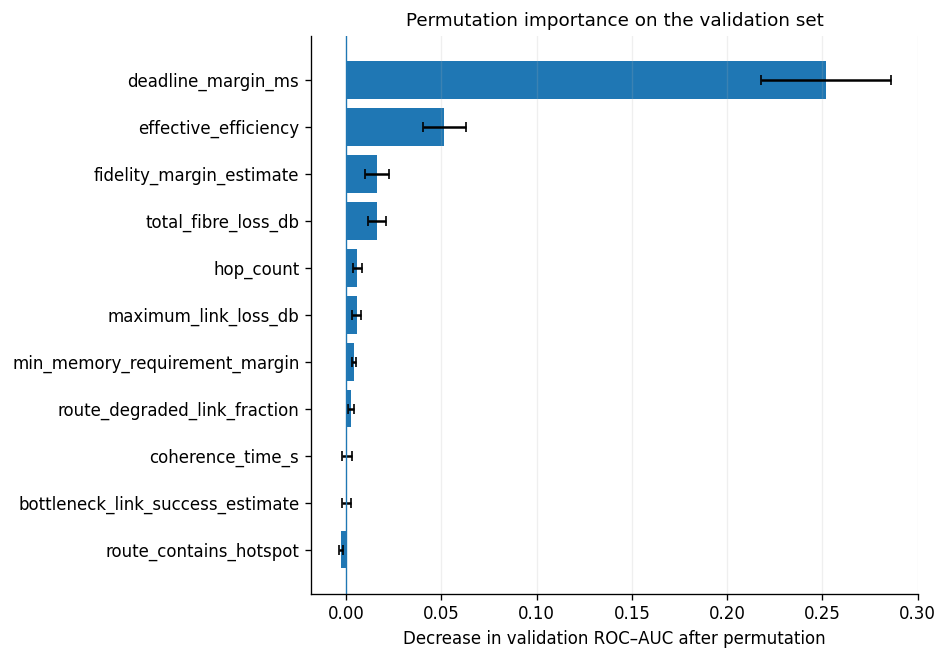

In [24]:
importance_result = permutation_importance(
    best_train_probability_model,
    X_validation,
    y_validation,
    scoring="roc_auc",
    n_repeats=PERMUTATION_REPEATS,
    random_state=RANDOM_SEED,
    n_jobs=N_JOBS,
)

permutation_importance_table = pd.DataFrame(
    {
        "Feature": MODEL_FEATURES,
        "Mean validation ROC-AUC decrease": importance_result.importances_mean,
        "SD validation ROC-AUC decrease": importance_result.importances_std,
    }
).sort_values("Mean validation ROC-AUC decrease", ascending=False)

display(permutation_importance_table)
permutation_importance_table.to_csv(
    EXPLANATION_DIR / "validation_permutation_importance.csv", index=False
)

plot_importance = permutation_importance_table.sort_values(
    "Mean validation ROC-AUC decrease", ascending=True
)
fig, ax = plt.subplots(figsize=(8.0, 5.6))
ax.barh(
    plot_importance["Feature"],
    plot_importance["Mean validation ROC-AUC decrease"],
    xerr=plot_importance["SD validation ROC-AUC decrease"],
    capsize=3,
)
ax.axvline(0, linewidth=0.8)
ax.set_xlabel("Decrease in validation ROC–AUC after permutation")
ax.set_title("Permutation importance on the validation set")
ax.grid(axis="x", alpha=0.2)
fig.tight_layout()
fig.savefig(
    EXPLANATION_DIR / "validation_permutation_importance.pdf",
    bbox_inches="tight",
)
fig.savefig(
    EXPLANATION_DIR / "validation_permutation_importance.png",
    bbox_inches="tight",
)
plt.show()

## 17. SHAP explanations on validation data

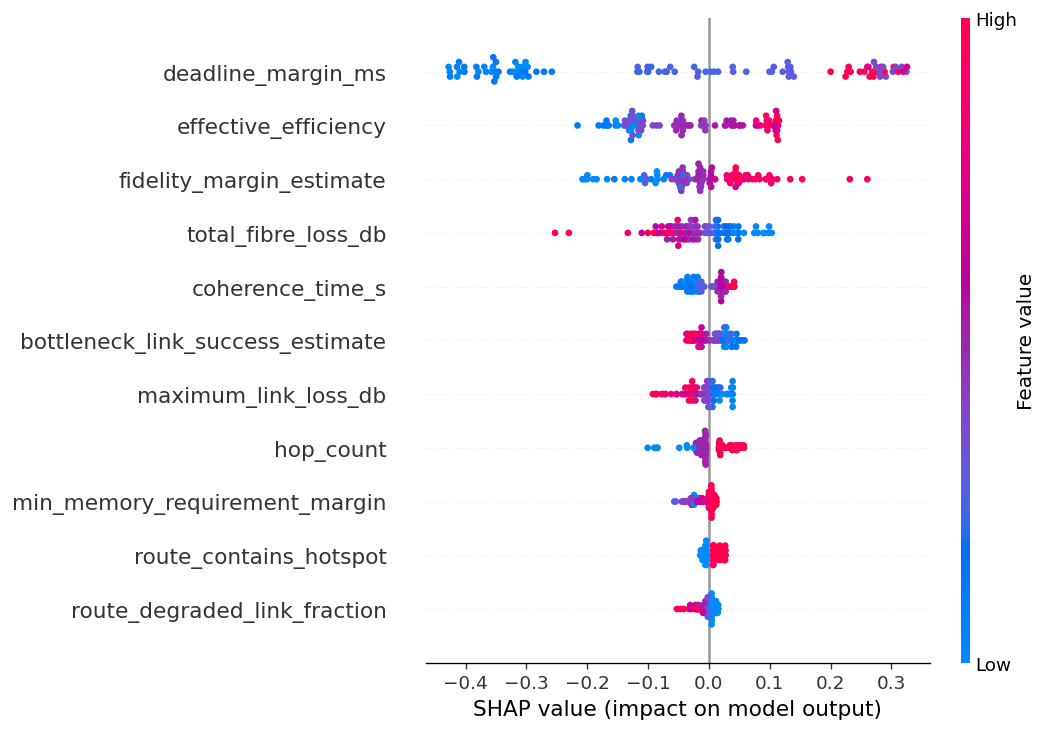

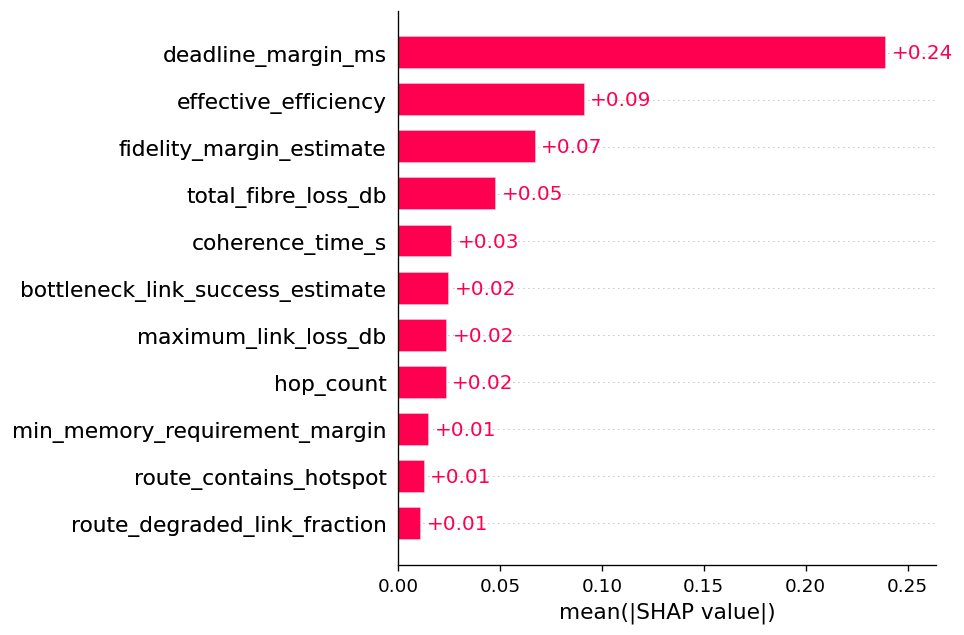

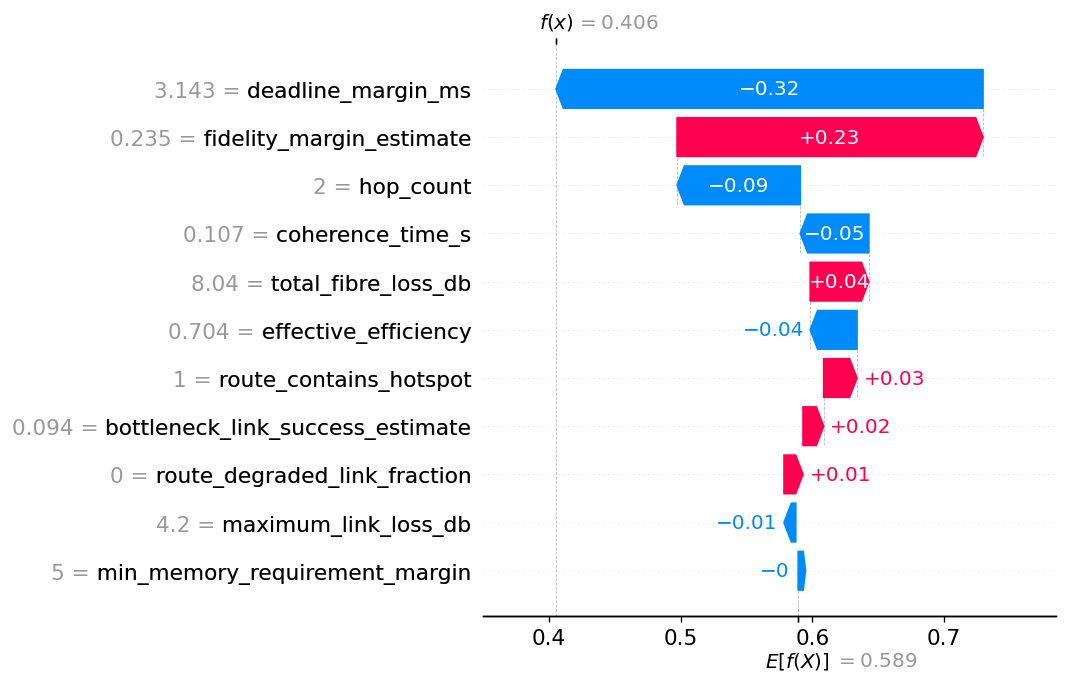

In [25]:
if RUN_EXPLAINABILITY:
    import shap

    def validation_model_probability(data: Any) -> np.ndarray:
        if isinstance(data, pd.DataFrame):
            frame = data.loc[:, MODEL_FEATURES]
        else:
            frame = pd.DataFrame(data, columns=MODEL_FEATURES)
        return best_train_probability_model.predict_proba(frame)[:, 1]

    background_size = min(SHAP_BACKGROUND_SIZE, len(X_train))
    explanation_size = min(SHAP_EXPLANATION_SIZE, len(X_validation))

    shap_background = shap.sample(
        X_train,
        background_size,
        random_state=RANDOM_SEED,
    )

    rng = np.random.default_rng(RANDOM_SEED)
    positive_indices = np.flatnonzero(y_validation.to_numpy() == 1)
    negative_indices = np.flatnonzero(y_validation.to_numpy() == 0)
    positive_count = min(len(positive_indices), explanation_size // 2)
    negative_count = min(len(negative_indices), explanation_size - positive_count)

    selected_indices = np.concatenate(
        [
            rng.choice(positive_indices, size=positive_count, replace=False),
            rng.choice(negative_indices, size=negative_count, replace=False),
        ]
    )

    if len(selected_indices) < explanation_size:
        remaining = np.setdiff1d(np.arange(len(X_validation)), selected_indices)
        extra = rng.choice(
            remaining,
            size=explanation_size - len(selected_indices),
            replace=False,
        )
        selected_indices = np.concatenate([selected_indices, extra])

    X_shap = X_validation.iloc[selected_indices].copy()
    masker = shap.maskers.Independent(shap_background)
    shap_explainer = shap.Explainer(
        validation_model_probability,
        masker,
        algorithm="permutation",
        feature_names=MODEL_FEATURES,
        seed=RANDOM_SEED,
    )

    shap_max_evals = (
        2 * len(MODEL_FEATURES) + 1
    ) * SHAP_PERMUTATION_CYCLES

    shap_values = shap_explainer(
        X_shap,
        max_evals=shap_max_evals,
        batch_size=16,
    )

    shap.plots.beeswarm(
        shap_values,
        max_display=len(MODEL_FEATURES),
        show=False,
    )
    plt.gcf().set_size_inches(9.0, 6.2)
    plt.tight_layout()
    plt.savefig(
        EXPLANATION_DIR / "shap_beeswarm_validation.pdf", bbox_inches="tight"
    )
    plt.savefig(
        EXPLANATION_DIR / "shap_beeswarm_validation.png", bbox_inches="tight"
    )
    plt.show()

    shap.plots.bar(
        shap_values,
        max_display=len(MODEL_FEATURES),
        show=False,
    )
    plt.gcf().set_size_inches(8.0, 5.4)
    plt.tight_layout()
    plt.savefig(
        EXPLANATION_DIR / "shap_global_bar_validation.pdf", bbox_inches="tight"
    )
    plt.savefig(
        EXPLANATION_DIR / "shap_global_bar_validation.png", bbox_inches="tight"
    )
    plt.show()

    local_validation_index = int(
        np.argmin(np.abs(validation_probability - OPERATING_THRESHOLD))
    )
    local_frame = X_validation.iloc[[local_validation_index]]
    local_shap = shap_explainer(local_frame, max_evals=shap_max_evals)

    shap.plots.waterfall(
        local_shap[0],
        max_display=len(MODEL_FEATURES),
        show=False,
    )
    plt.gcf().set_size_inches(9.0, 5.8)
    plt.tight_layout()
    plt.savefig(
        EXPLANATION_DIR / "shap_local_waterfall_validation.pdf",
        bbox_inches="tight",
    )
    plt.savefig(
        EXPLANATION_DIR / "shap_local_waterfall_validation.png",
        bbox_inches="tight",
    )
    plt.show()

    shap_local_metadata_columns = [
        column
        for column in [
            GROUP_COLUMN,
            RANKING_GROUP_COLUMN,
            "pair_id",
            "route_id",
            "path_string",
            "difficulty",
            TARGET,
            PROBABILITY_TARGET,
        ]
        if column in validation_df.columns
    ]
    shap_local_metadata = validation_df.iloc[[local_validation_index]][
        shap_local_metadata_columns
    ].copy()
    shap_local_metadata["predicted_probability"] = validation_probability[
        local_validation_index
    ]
    shap_local_metadata["locked_threshold"] = OPERATING_THRESHOLD
    shap_local_metadata.to_csv(
        EXPLANATION_DIR / "shap_local_validation_case_metadata.csv",
        index=False,
    )
else:
    print("SHAP skipped because RUN_EXPLAINABILITY=False")

## 18. LIME explanation and multi-seed stability on the same validation case

,Feature,mean_weight,sd_weight,mean_absolute_weight,positive_fraction,runs,sign_consistency
2,deadline_margin_ms,-0.541054,0.005244,0.541054,0.0,5,1.0
4,fidelity_margin_estimate,0.171164,0.013189,0.171164,1.0,5,1.0
10,total_fibre_loss_db,0.087818,0.007565,0.087818,1.0,5,1.0
5,hop_count,-0.064648,0.003222,0.064648,0.0,5,1.0
1,coherence_time_s,-0.049334,0.003633,0.049334,0.0,5,1.0
3,effective_efficiency,-0.036391,0.010647,0.036391,0.0,5,1.0
7,min_memory_requirement_margin,0.033626,0.006556,0.033626,1.0,5,1.0
8,route_contains_hotspot,0.027403,0.005940,0.027403,1.0,5,1.0
9,route_degraded_link_fraction,0.017930,0.009595,0.017930,1.0,5,1.0
0,bottleneck_link_success_estimate,0.016579,0.008634,0.016579,1.0,5,1.0


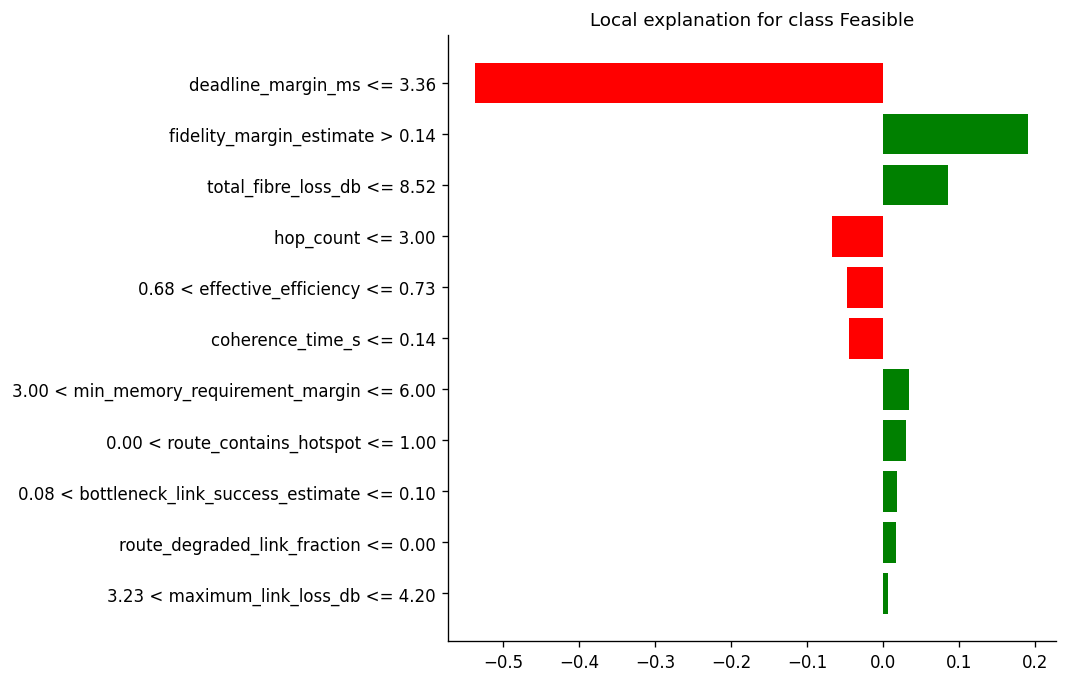

In [26]:
if RUN_EXPLAINABILITY:
    from lime.lime_tabular import LimeTabularExplainer

    lime_index = int(
        np.argmin(np.abs(validation_probability - OPERATING_THRESHOLD))
    )

    def lime_predict_proba(array: np.ndarray) -> np.ndarray:
        frame = pd.DataFrame(array, columns=MODEL_FEATURES)
        return best_train_probability_model.predict_proba(frame)

    def lime_condition_feature(condition: str) -> str:
        matches = [feature for feature in MODEL_FEATURES if feature in condition]
        if not matches:
            return "UNMAPPED"
        return sorted(matches, key=len, reverse=True)[0]

    lime_runs = []
    primary_lime_explanation = None

    for lime_seed in LIME_SEEDS:
        lime_explainer = LimeTabularExplainer(
            training_data=X_train.to_numpy(dtype=float),
            feature_names=MODEL_FEATURES,
            class_names=["Infeasible", "Feasible"],
            mode="classification",
            discretize_continuous=True,
            random_state=lime_seed,
        )

        explanation = lime_explainer.explain_instance(
            data_row=X_validation.iloc[lime_index].to_numpy(dtype=float),
            predict_fn=lime_predict_proba,
            labels=(1,),
            num_features=len(MODEL_FEATURES),
            num_samples=LIME_NUM_SAMPLES,
        )

        if primary_lime_explanation is None:
            primary_lime_explanation = explanation

        for condition, weight in explanation.as_list(label=1):
            lime_runs.append(
                {
                    "Seed": lime_seed,
                    "Feature": lime_condition_feature(condition),
                    "Feature condition": condition,
                    "LIME weight for feasible class": weight,
                }
            )

    lime_all_runs = pd.DataFrame(lime_runs)
    lime_all_runs.to_csv(
        EXPLANATION_DIR / "lime_validation_all_seed_runs.csv", index=False
    )

    lime_stability = (
        lime_all_runs.loc[lime_all_runs["Feature"] != "UNMAPPED"]
        .groupby("Feature", as_index=False)
        .agg(
            mean_weight=("LIME weight for feasible class", "mean"),
            sd_weight=("LIME weight for feasible class", "std"),
            mean_absolute_weight=(
                "LIME weight for feasible class",
                lambda values: np.mean(np.abs(values)),
            ),
            positive_fraction=(
                "LIME weight for feasible class",
                lambda values: np.mean(np.asarray(values) > 0),
            ),
            runs=("LIME weight for feasible class", "size"),
        )
        .sort_values("mean_absolute_weight", ascending=False)
    )
    lime_stability["sign_consistency"] = np.maximum(
        lime_stability["positive_fraction"],
        1 - lime_stability["positive_fraction"],
    )

    display(lime_stability)
    lime_stability.to_csv(
        EXPLANATION_DIR / "lime_validation_stability.csv", index=False
    )

    if primary_lime_explanation is None:
        raise RuntimeError("LIME did not produce an explanation.")

    primary_lime_explanation.save_to_file(
        str(EXPLANATION_DIR / "lime_validation_explanation.html")
    )
    lime_figure = primary_lime_explanation.as_pyplot_figure(label=1)
    lime_figure.set_size_inches(9.0, 5.8)
    lime_figure.tight_layout()
    lime_figure.savefig(
        EXPLANATION_DIR / "lime_validation_explanation.pdf", bbox_inches="tight"
    )
    lime_figure.savefig(
        EXPLANATION_DIR / "lime_validation_explanation.png", bbox_inches="tight"
    )
    plt.show()

    lime_metadata_columns = [
        column
        for column in [
            GROUP_COLUMN,
            RANKING_GROUP_COLUMN,
            "pair_id",
            "route_id",
            "path_string",
            "difficulty",
            TARGET,
            PROBABILITY_TARGET,
        ]
        if column in validation_df.columns
    ]
    lime_case_metadata = validation_df.iloc[[lime_index]][lime_metadata_columns].copy()
    lime_case_metadata["predicted_probability"] = validation_probability[lime_index]
    lime_case_metadata["locked_threshold"] = OPERATING_THRESHOLD
    lime_case_metadata["case_type"] = "validation route nearest locked threshold"
    lime_case_metadata.to_csv(
        EXPLANATION_DIR / "lime_validation_case_metadata.csv", index=False
    )
else:
    print("LIME skipped because RUN_EXPLAINABILITY=False")

## 19. Export predictions, model, checksums, metadata, and ZIP archive

In [27]:
def prediction_export(
    source_frame: pd.DataFrame,
    probabilities: np.ndarray,
    split_name: str,
) -> pd.DataFrame:
    identifier_columns = [
        column
        for column in [
            "topology_id",
            GROUP_COLUMN,
            RANKING_GROUP_COLUMN,
            "pair_id",
            "route_id",
            "path_string",
            "difficulty",
            TARGET,
            PROBABILITY_TARGET,
        ]
        if column in source_frame.columns
    ]

    exported = source_frame[identifier_columns].copy().reset_index(drop=True)
    exported["evaluation_split"] = split_name
    exported["predicted_feasibility_class_probability"] = np.asarray(
        probabilities, dtype=float
    )
    exported["predicted_feasible_label"] = (
        exported["predicted_feasibility_class_probability"] >= OPERATING_THRESHOLD
    ).astype(int)
    return exported


train_predictions = prediction_export(
    train_df, train_nested_oof_probability, "Train nested OOF"
)
validation_predictions = prediction_export(
    validation_df, validation_probability, "Validation"
)
test_predictions = prediction_export(
    test_df, test_probability, "External test"
)

all_predictions = pd.concat(
    [train_predictions, validation_predictions, test_predictions],
    ignore_index=True,
)
all_predictions.to_csv(TABLE_DIR / "all_split_predictions.csv", index=False)

joblib.dump(
    best_train_probability_model,
    MODEL_DIR / "training_only_probability_model.joblib",
)
joblib.dump(final_model, MODEL_DIR / "final_development_fitted_model.joblib")


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


input_checksums = {
    "train": {"path": str(TRAIN_PATH), "sha256": sha256_file(TRAIN_PATH)},
    "validation": {
        "path": str(VALIDATION_PATH),
        "sha256": sha256_file(VALIDATION_PATH),
    },
    "external_test": {"path": str(TEST_PATH), "sha256": sha256_file(TEST_PATH)},
}

package_versions = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scipy": scipy.__version__,
    "scikit_learn": sklearn.__version__,
    "joblib": joblib.__version__,
}

if RUN_EXPLAINABILITY:
    import shap
    import lime

    package_versions["shap"] = shap.__version__
    package_versions["lime"] = getattr(lime, "__version__", "not exposed")

metadata = {
    "random_seed": RANDOM_SEED,
    "selected_model_family": BEST_MODEL_NAME,
    "selected_hyperparameters": BEST_HYPERPARAMETERS,
    "models_within_one_standard_error": model_comparison.loc[
        model_comparison["Within one SE of best"], "Model"
    ].tolist(),
    "model_features": MODEL_FEATURES,
    "target": TARGET,
    "probability_target": PROBABILITY_TARGET,
    "group_column": GROUP_COLUMN,
    "ranking_group_column": RANKING_GROUP_COLUMN,
    "simulation_feasibility_threshold": FEASIBILITY_THRESHOLD,
    "classification_operating_threshold": OPERATING_THRESHOLD,
    "threshold_bootstrap_95ci": [
        float(np.percentile(threshold_bootstrap_values, 2.5)),
        float(np.percentile(threshold_bootstrap_values, 97.5)),
    ],
    "model_selection_protocol": (
        "Five-fold outer and four-fold inner StratifiedGroupKFold on training "
        "scenario_group_id; final selected-family hyperparameter search on all training data"
    ),
    "validation_role": (
        "Out-of-sample threshold selection and interpretability; no model-family selection"
    ),
    "external_test_role": "Locked one-time unseen-topology evaluation",
    "bootstrap_unit": GROUP_COLUMN,
    "bootstrap_replicates": N_BOOTSTRAP,
    "ranking_bootstrap_replicates": RANKING_BOOTSTRAP,
    "routing_policy_baselines": ROUTING_POLICY_ORDER,
    "routing_policy_random_baseline": (
        "Exact expectation under uniform random route selection"
    ),
    "input_checksums": input_checksums,
    "package_versions": package_versions,
    "fast_mode": FAST_MODE,
    "run_explainability": RUN_EXPLAINABILITY,
}

with (OUTPUT_DIR / "experiment_metadata.json").open("w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2, sort_keys=True)

with (OUTPUT_DIR / "requirements_observed.txt").open("w", encoding="utf-8") as file:
    for package, version in package_versions.items():
        file.write(f"{package}=={version}\n")

archive_path = shutil.make_archive(
    str(OUTPUT_DIR),
    "zip",
    root_dir=OUTPUT_DIR,
)

print("Final model:", MODEL_DIR / "final_development_fitted_model.joblib")
print("All outputs:", OUTPUT_DIR)
print("ZIP archive:", archive_path)

Final model: /content/final_classical_ml_quantum_routing_results/models/final_development_fitted_model.joblib
All outputs: /content/final_classical_ml_quantum_routing_results
ZIP archive: /content/final_classical_ml_quantum_routing_results.zip
